In [1]:
import awkward as ak
import numba
import numpy as np
import pandas as pd
import awkward as ak
import vector
from scipy.special import softmax
vector.register_numba()
vector.register_awkward()
import os

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import mplhep as hep
hep.style.use(hep.style.ROOT)

import numba
import h5py
import yaml

import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import onnxruntime    # to inference ONNX models, we use the ONNX Runtime

In [2]:
def plot_confusion_matrix(y_true, y_pred, output, norm=None, class_names=None, title=None, cmap='Blues', weights=None):

    # Compute confusion matrix with optional sample weights
    cm = confusion_matrix(y_true, y_pred, normalize=norm, sample_weight=weights)[1:, 1:] #remove 1st col and row bc empty

    if class_names is not None:
        labels = class_names
    else:
        labels = np.arange(cm.shape[0])
    
    # Plotting
    plt.figure(figsize=(12, 12), dpi=100)
    sns.heatmap(cm, annot=True, cmap=cmap, xticklabels=labels, yticklabels=labels, fmt=".2f")
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(output, dpi=100)
    plt.show()

def plot_roc(true_label, pred_label, ax, label, weight=None):
    fontsize = 16
    fontsize_legend = 10
    fpr, tpr, thresholds = roc_curve(true_label, pred_label, sample_weight=weight)
    i_sorted = np.argsort(fpr)
    AUC = auc(fpr[i_sorted], tpr[i_sorted])
    ax.plot(tpr, fpr, label=f"{label} AUC={round(AUC, 3)}")
    ax.set_yscale("log")
    ax.set_title(f"{label} score", fontsize=fontsize)
    ax.set_xlabel("Signal efficiency", fontsize=fontsize)
    ax.set_ylabel("Background efficiency", fontsize=fontsize)
    ax.legend(fontsize=fontsize_legend)

def plot_rocs(true_labels, pred_labels, weight=None):
    fig, axes = plt.subplots(3, 3, figsize=[18,18])
    for i, label in enumerate(pred_labels.keys()):
        ax = axes[i // 3][i % 3]#[i % 2][int(i / 2)]
        true_label = true_labels[label]
        pred_label = pred_labels[label]
        plot_roc(true_label, pred_label, ax, label)
        plot_roc(true_label, pred_label, ax, label+" weighed", weight=weight)
    fig.tight_layout(pad=2.5)

def plot_correlation_matrix_numpy(numpy_array, output, feature_names=None, title="Correlation Matrix", annot=True, cmap="coolwarm"):
    """
    Plots the correlation matrix from a NumPy array and saves it to a file.

    Args:
        numpy_array (np.ndarray): A NumPy array of shape [N, M], where M is the
                                   number of features.
        output (str): Path to the output PNG file.
        feature_names (list of str, optional): List of feature names to be used as
                                               labels for the plot. Defaults to None.
        title (str, optional): Title of the plot. Defaults to "Correlation Matrix".
        annot (bool, optional): Whether to display correlation coefficients in the
                                heatmap. Defaults to True.
        cmap (str, optional): Colormap to use for the heatmap. Defaults to "coolwarm".
    """
    
    # Ensure output directory exists
    os.makedirs(os.path.dirname(output), exist_ok=True)

    num_features = numpy_array.shape[1]
    if feature_names is None:
        feature_names = [f'Feature {i+1}' for i in range(num_features)]
    elif len(feature_names) != num_features:
        raise ValueError(f"Length of feature_names ({len(feature_names)}) must match the number of features in the array ({num_features}).")

    # Convert NumPy array to pandas DataFrame
    df = pd.DataFrame(numpy_array, columns=feature_names)

    # Calculate the correlation matrix
    corr_matrix = df.corr()

    # Create the heatmap
    plt.figure(figsize=(12, 12), dpi=100)
    sns.heatmap(corr_matrix, annot=annot, cmap=cmap, xticklabels=feature_names, yticklabels=feature_names)
    plt.title(title)
    plt.tight_layout()

    # Save the figure
    plt.savefig(output)
    plt.close()

def plot_significance(signal, background, bins=30, range=(0, 1), title="Signal significance", xlabel="Bins", ylabel="$S/\\sqrt{B}$", output_path=None):
    """
    Plots the significance (S/sqrt(B)) as a function of score or any other variable.
        signal (array-like): Array of signal scores or weights.
        background (array-like): Array of background scores or weights.
        bins (int): Number of bins for the histograms.
        range (tuple): (min, max) range for binning.
        title (str): Plot title.
        xlabel (str): Label for x-axis.
        ylabel (str): Label for y-axis.
        output_path (str): If given, saves the figure to this path.
    """

    # Histogram signal and background
    #s_hist, bin_edges = np.histogram(signal, bins=bins, range=range)
    #b_hist, _ = np.histogram(background, bins=bins, range=range)

    # To avoid division by zero, replace 0 background counts with a small number
    #b_hist_safe = np.where(b_hist == 0, 1e-6, b_hist)
    
    thresholds = np.linspace(0, 1, 100)

    # Calculate significance for each threshold
    significance = np.zeros_like(thresholds, dtype=float)
    signal_counts = np.zeros_like(thresholds, dtype=float)
    background_counts = np.zeros_like(thresholds, dtype=float)
    
    # Count signal and background above each threshold
    for i, thr in enumerate(thresholds):
        signal_counts[i] = np.sum(signal >= thr)
        background_counts[i] = np.sum(background >= thr)
    
    mask = background_counts > 0
    significance[mask] = signal_counts[mask] / np.sqrt(background_counts[mask])
    
    #bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    plt.figure(figsize=(8, 8))
    plt.plot(thresholds, significance, marker='o', label='Significance $S/\\sqrt{B}$')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path)
        print(f"Saved plot to {output_path}")
    plt.show()

In [3]:
def plot_score(pred_label, score, label, ax, weights=None, title=None, mask=None, log=False, ylim=None, density=False, legend=True):
    if mask is not None:
        pred_label = pred_label[mask]
        if weights is not None:
            weights = weights[mask]
    color = colors.get(label, ax._get_lines.get_next_color())
    n, bins, patches = ax.hist(pred_label, bins=50, range=(0,1),
                               weights=weights, histtype="step",
                               linewidth=2, color=color, label=labels_legend.get(label), density=density)
    if legend:
        ax.legend(fontsize=15)
    ax.set_xlabel(f"{labels_legend.get(score)} SPANet score")
    ax.set_ylabel("A.U." if density else "Counts")
    if log:
        ax.set_yscale("log")
    if ylim is not None:
        ax.set_ylim(*ylim)
    if title:
        ax.set_title(title)
    return n, bins, patches


def plot_scores(true_labels, pred_labels, plot_dir=None, weights=None, title=None, mask=None, log=False, ylim=None, density=False):
    score_names = list(pred_labels.keys())
    n_scores = len(score_names)
    n_cols = 3 if n_scores > 3 else n_scores
    n_rows = int(np.ceil(n_scores / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=[24,20], dpi=100)#figsize=[7 * n_cols, 5 * n_rows], dpi=100)
    axes = np.atleast_2d(axes)
    for i, score in enumerate(score_names):
        ax = axes[i // n_cols][i % n_cols]
        for label in true_labels:
            mask_by_sample = true_labels[label]
            if mask is not None:
                mask_by_sample &= mask
            plot_score(pred_labels[score], score, label, ax=ax,
                       mask=mask_by_sample, weights=weights,
                       title=title, log=log, ylim=ylim, density=density)

    for j in range(n_scores, n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis("off")

    fig.tight_layout(pad=1.5)
    if plot_dir:
        filename = os.path.join(plot_dir, "classification_scores.png")
        if weights is not None:
            filename = filename.replace(".png","_weighted.png")
        if log:
            filename = filename.replace(".png","_log.png")
        if density:
            filename = filename.replace(".png","_normalised.png")
        plt.savefig(filename, dpi=300)
    plt.show()

In [4]:
# Test on 2024 only
h5_file = "/home/mmarcheg/work/ttHbb/ntuples/fullyhadronic_ttH_export-inference/h5/output_2024_test_14270152.h5"
config = "/home/mmarcheg/work/ttHbb/models/multiclassifier_btag_TML/spanet_output/version_0/event.yaml"

In [5]:
f = h5py.File(h5_file, 'r')
f.keys()

<KeysViewHDF5 ['CLASSIFICATIONS', 'INPUTS', 'SPANET_OUTPUT', 'TARGETS', 'WEIGHTS']>

In [6]:
jet_data = f["INPUTS"]["Jet"]
met_data = f["INPUTS"]["Met"]
event_data = f["INPUTS"]["Event"]
weights = f["WEIGHTS"]["weight"]

In [7]:
weights[()]

array([0.19562271, 0.20743573, 0.18418169, ..., 0.00044192, 0.06802622,
       0.20209683], dtype=float32)

In [8]:
inverse_mapping_encoding = {
    "tthbb": 1,
    "qcd": 2,
    "ttlf": 3,
    "ttcc": 4,
    "ttbb": 5,
    "singletop": 6,
    "ttv": 7,
    "vjets": 8,
    "tthnonbb": 9
}

cl_out = [np.zeros_like(weights)]
for label in f["SPANET_OUTPUT"]:
    print(label, f["SPANET_OUTPUT"][label].shape)
    cl_out.append(f["SPANET_OUTPUT"][label][()])
cl_out = np.stack(cl_out, axis=1)

qcd (14270152,)
singletop (14270152,)
ttbb (14270152,)
ttcc (14270152,)
tthbb (14270152,)
tthnonbb (14270152,)
ttlf (14270152,)
ttv (14270152,)
vjets (14270152,)


In [9]:
cl_out

array([[0.        , 0.06145763, 0.14795372, ..., 0.21554317, 0.18520801,
        0.06227965],
       [0.        , 0.48412293, 0.10953342, ..., 0.03590801, 0.02032047,
        0.29235876],
       [0.        , 0.11427053, 0.13057391, ..., 0.06430157, 0.25461876,
        0.14748876],
       ...,
       [0.        , 0.03515174, 0.07494116, ..., 0.24970135, 0.1829653 ,
        0.03533543],
       [0.        , 0.00337888, 0.06715322, ..., 0.1934551 , 0.2488914 ,
        0.00540228],
       [0.        , 0.2353857 , 0.1264236 , ..., 0.13996905, 0.05411101,
        0.21152909]], dtype=float32)

In [10]:
cl_out[1,:]

array([0.        , 0.48412293, 0.10953342, 0.01428879, 0.02521097,
       0.00740377, 0.01085287, 0.03590801, 0.02032047, 0.29235876],
      dtype=float32)

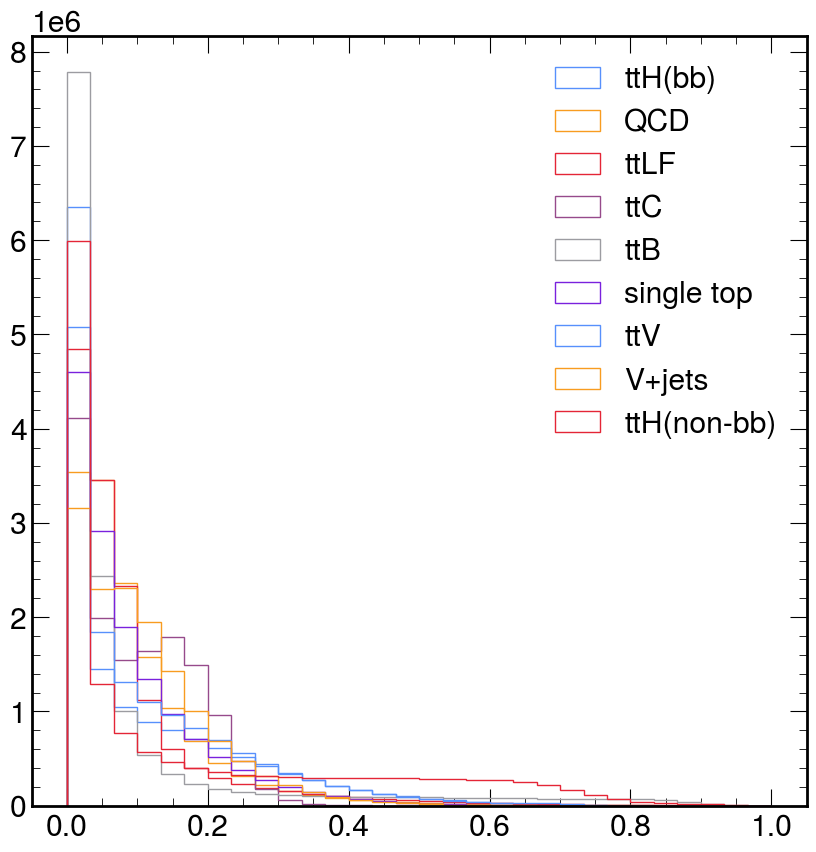

In [11]:
mapping_encoding = {
    1: "ttH(bb)",
    2: "QCD",
    3: "ttLF",
    4: "ttC",
    5: "ttB",
    6: "single top",
    7: "ttV",
    8: "V+jets",
    9: "ttH(non-bb)",
}

Nclasses = len(mapping_encoding) + 1

for i in range(1, Nclasses):
    plt.hist(cl_out[:,i], range=(0,1), bins=30, histtype='step', label=mapping_encoding[i])
plt.legend()
#plt.hist(cl_out[:,0])SoftmaxEVENT

(array([8.782823e+06, 2.379668e+06, 1.570612e+06, 8.451210e+05,
        4.093800e+05, 1.825290e+05, 7.200900e+04, 2.276600e+04,
        4.875000e+03, 3.690000e+02]),
 array([6.02556156e-06, 9.79297161e-02, 1.95853397e-01, 2.93777108e-01,
        3.91700774e-01, 4.89624470e-01, 5.87548137e-01, 6.85471833e-01,
        7.83395529e-01, 8.81319225e-01, 9.79242921e-01]),
 <BarContainer object of 10 artists>)

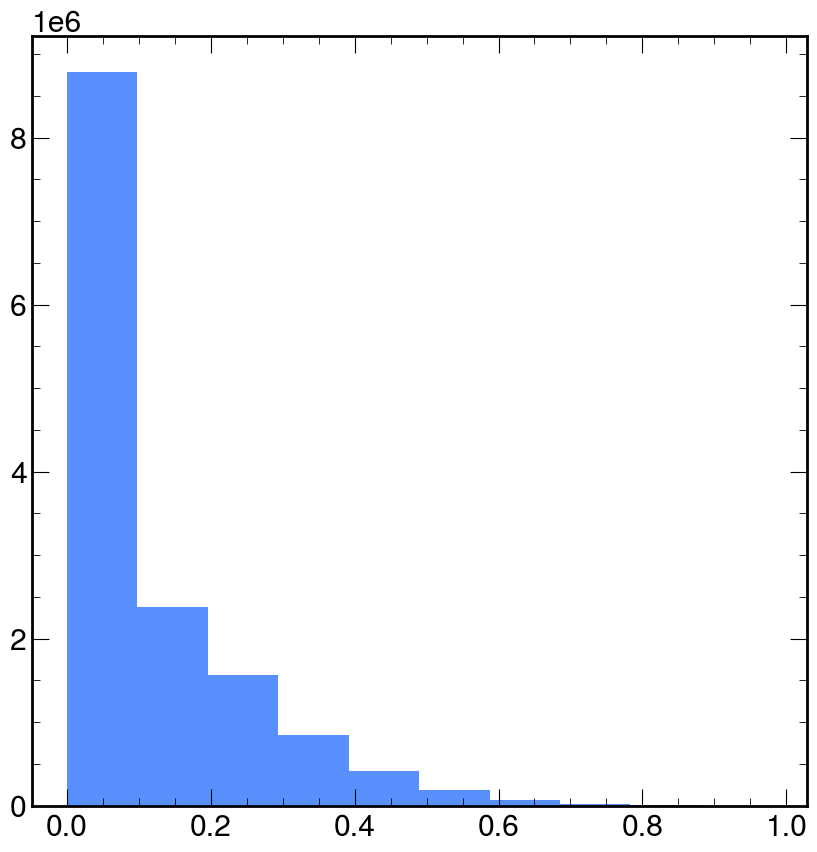

In [65]:
plt.hist(cl_out[:,1])

(array([9.072497e+06, 3.409076e+06, 1.077197e+06, 4.015910e+05,
        1.728670e+05, 7.906300e+04, 3.511400e+04, 1.467200e+04,
        6.351000e+03, 1.724000e+03]),
 array([1.00824196e-04, 9.50609967e-02, 1.90021172e-01, 2.84981340e-01,
        3.79941523e-01, 4.74901706e-01, 5.69861889e-01, 6.64822042e-01,
        7.59782195e-01, 8.54742408e-01, 9.49702561e-01]),
 <BarContainer object of 10 artists>)

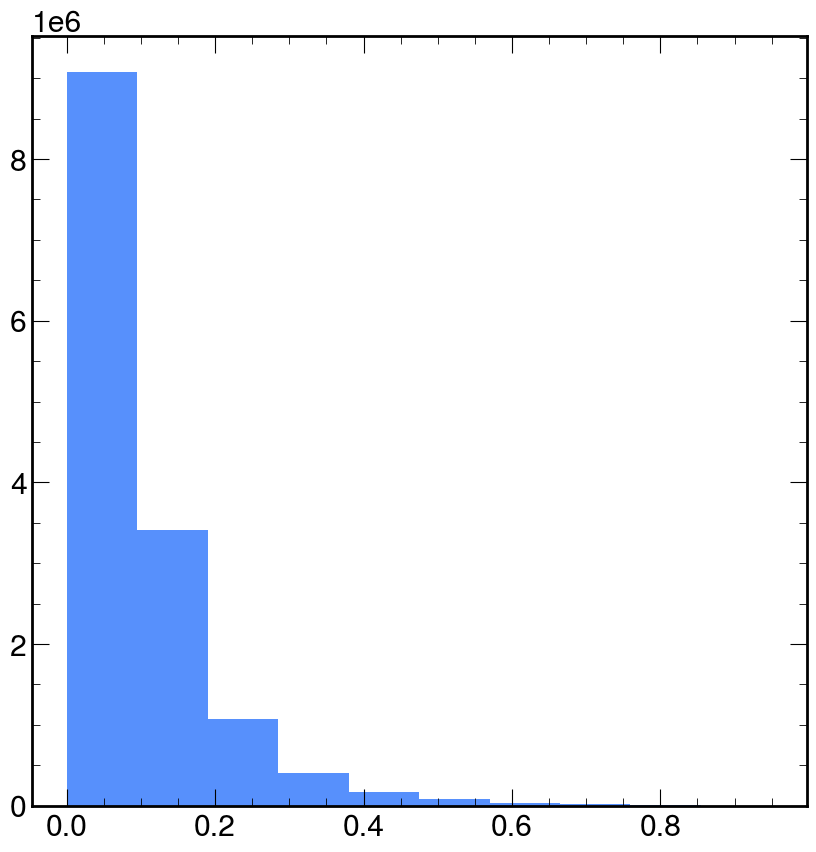

In [66]:
plt.hist(cl_out[:,2])

In [67]:
f.keys()

<KeysViewHDF5 ['CLASSIFICATIONS', 'INPUTS', 'SPANET_OUTPUT', 'TARGETS', 'WEIGHTS']>

In [68]:
y_true = f["CLASSIFICATIONS"]["EVENT"]["signal"][()]

In [69]:
y_pred = np.argmax(cl_out, axis=1)

In [70]:
cl_out

array([[0.        , 0.06145763, 0.14795372, ..., 0.21554317, 0.18520801,
        0.06227965],
       [0.        , 0.48412293, 0.10953342, ..., 0.03590801, 0.02032047,
        0.29235876],
       [0.        , 0.11427053, 0.13057391, ..., 0.06430157, 0.25461876,
        0.14748876],
       ...,
       [0.        , 0.03515174, 0.07494116, ..., 0.24970135, 0.1829653 ,
        0.03533543],
       [0.        , 0.00337888, 0.06715322, ..., 0.1934551 , 0.2488914 ,
        0.00540228],
       [0.        , 0.2353857 , 0.1264236 , ..., 0.13996905, 0.05411101,
        0.21152909]], dtype=float32)

In [71]:
labels = list(mapping_encoding.values())
out_folder = "plots_multiclassifier_btag_TML"

In [72]:
true_labels = {}
pred_labels = {}
for index, label in zip(range(1, Nclasses), labels):
    true_labels[label] = np.array(y_true == index)
    pred_labels[label] = np.array(cl_out[:,index])

In [73]:
pred_labels

{'ttH(bb)': array([0.06145763, 0.48412293, 0.11427053, ..., 0.03515174, 0.00337888,
        0.2353857 ], dtype=float32),
 'QCD': array([0.14795372, 0.10953342, 0.13057391, ..., 0.07494116, 0.06715322,
        0.1264236 ], dtype=float32),
 'ttLF': array([0.05975766, 0.01428879, 0.03360589, ..., 0.08708841, 0.08422204,
        0.05859818], dtype=float32),
 'ttC': array([0.15410632, 0.02521097, 0.08950739, ..., 0.20716944, 0.19171083,
        0.14063215], dtype=float32),
 'ttB': array([0.02687002, 0.00740377, 0.02921626, ..., 0.03338196, 0.03735789,
        0.00897488], dtype=float32),
 'single top': array([0.0868238 , 0.01085287, 0.13641694, ..., 0.0942652 , 0.16842833,
        0.02437638], dtype=float32),
 'ttV': array([0.21554317, 0.03590801, 0.06430157, ..., 0.24970135, 0.1934551 ,
        0.13996905], dtype=float32),
 'V+jets': array([0.18520801, 0.02032047, 0.25461876, ..., 0.1829653 , 0.2488914 ,
        0.05411101], dtype=float32),
 'ttH(non-bb)': array([0.06227965, 0.29235876, 0.

In [74]:
weights = f["WEIGHTS"]["weight"][()]
weights.shape

(14270152,)

/tmp/ipykernel_14919/612175164.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout(pad=2.5)
/home/mmarcheg/.local/micromamba/envs/tthbb-spanet/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/mmarcheg/.local/micromamba/envs/tthbb-spanet/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


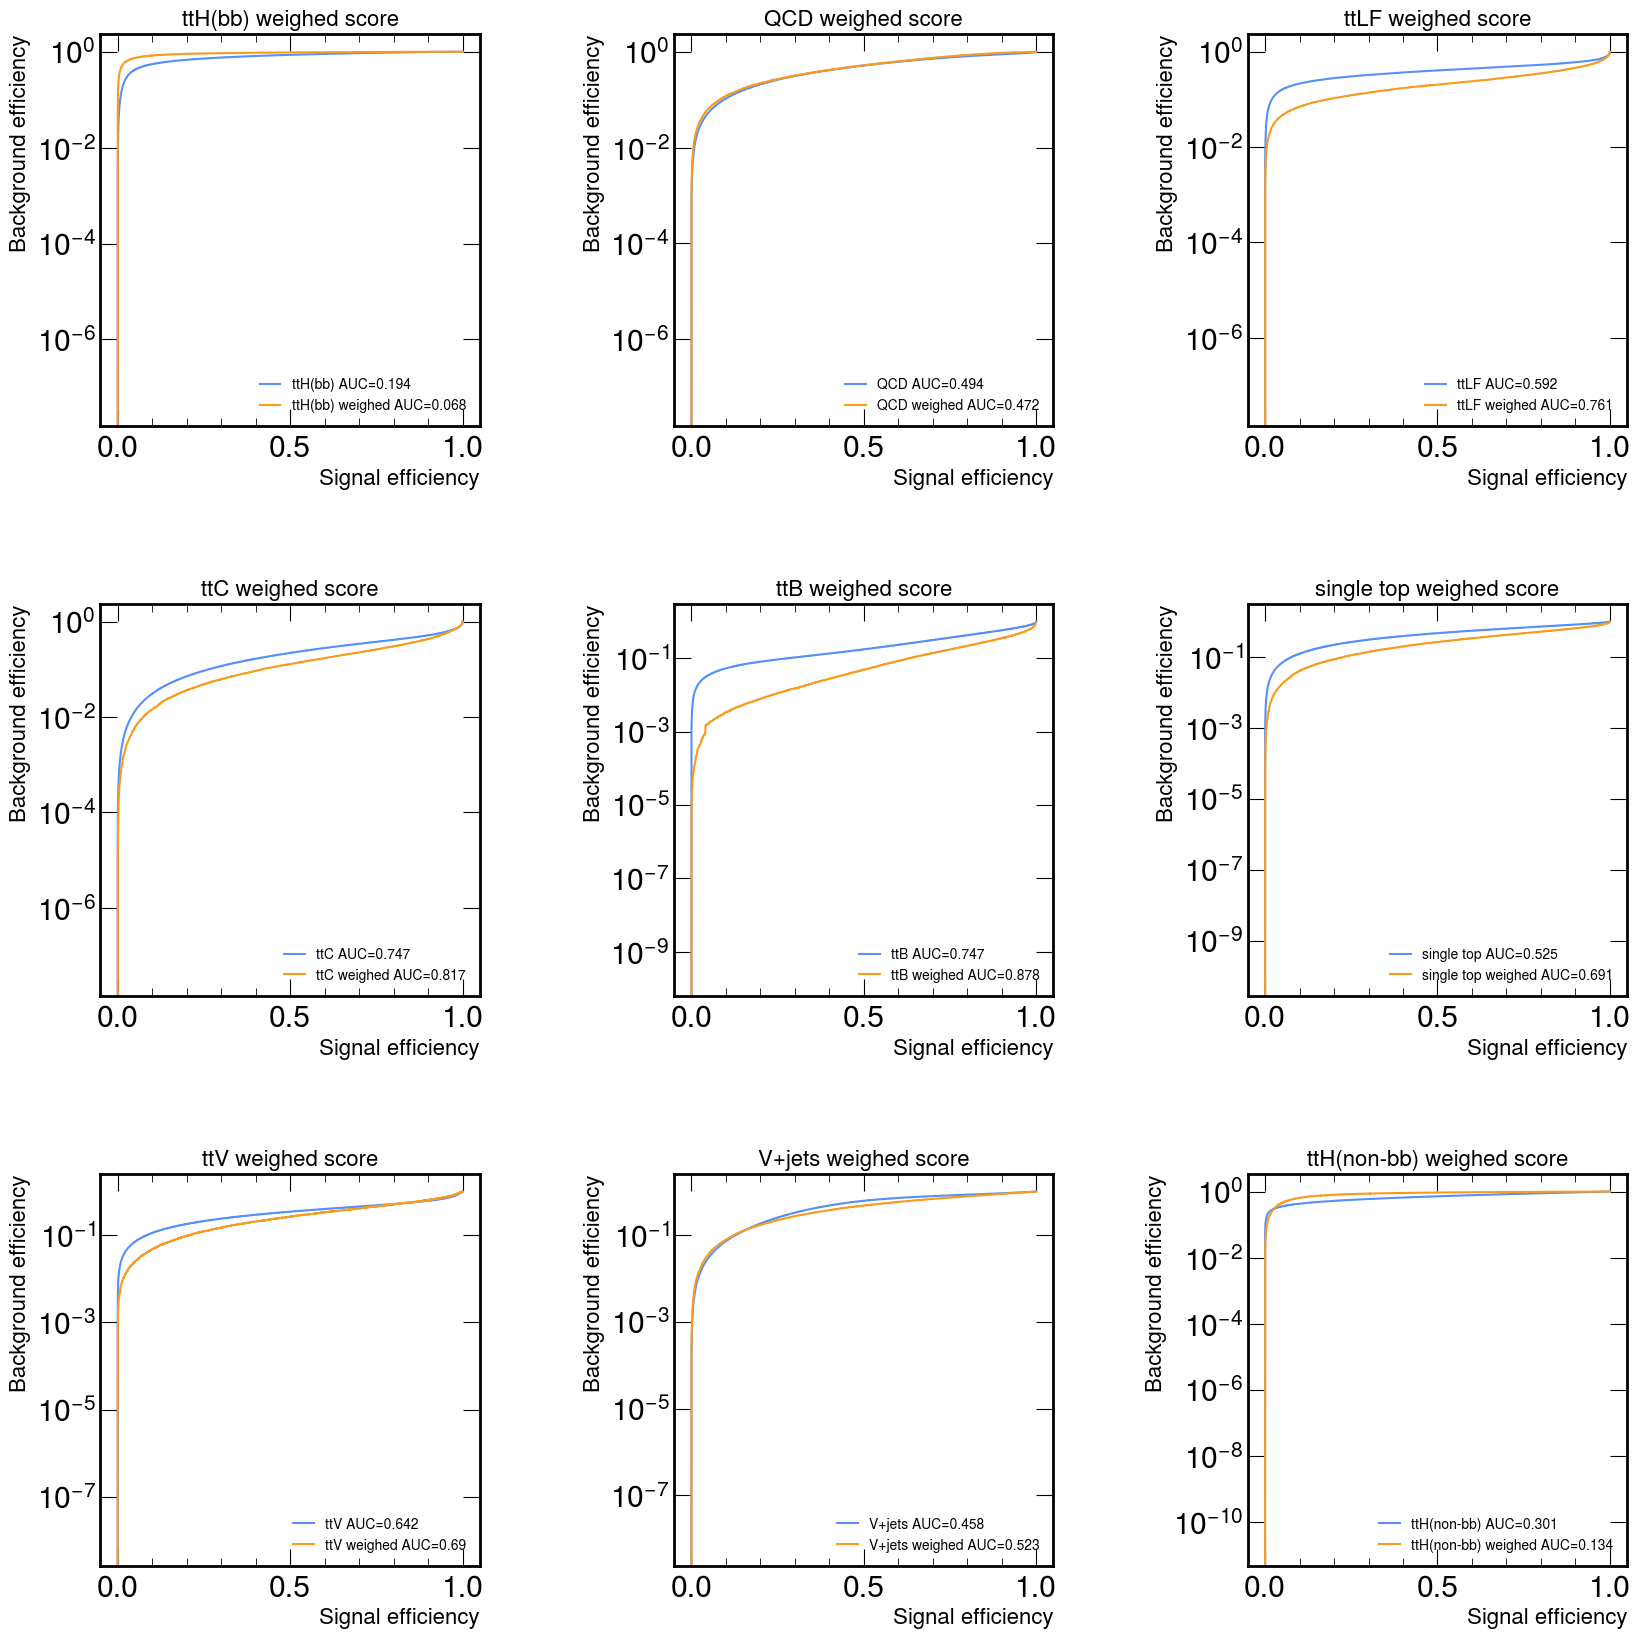

In [75]:
plot_rocs(true_labels, pred_labels, weight=weights[:])

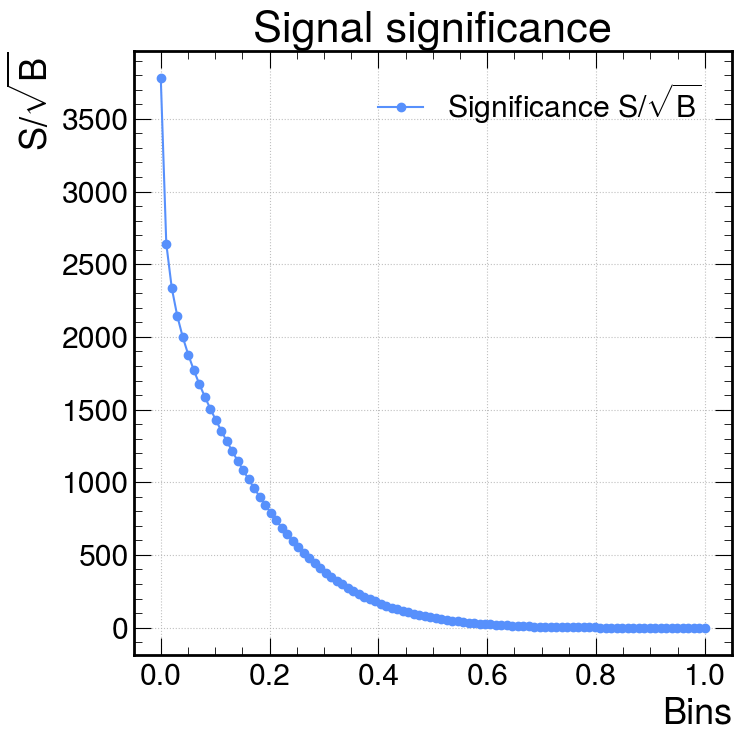

In [76]:
#true_signal = true_labels["ttHbb"]
pred_signal = cl_out[:,1] #pred_labels["ttHbb"]
pred_bkg = np.sum(cl_out[:, 2:], axis=1)
plot_significance(pred_signal, pred_bkg, bins=100)

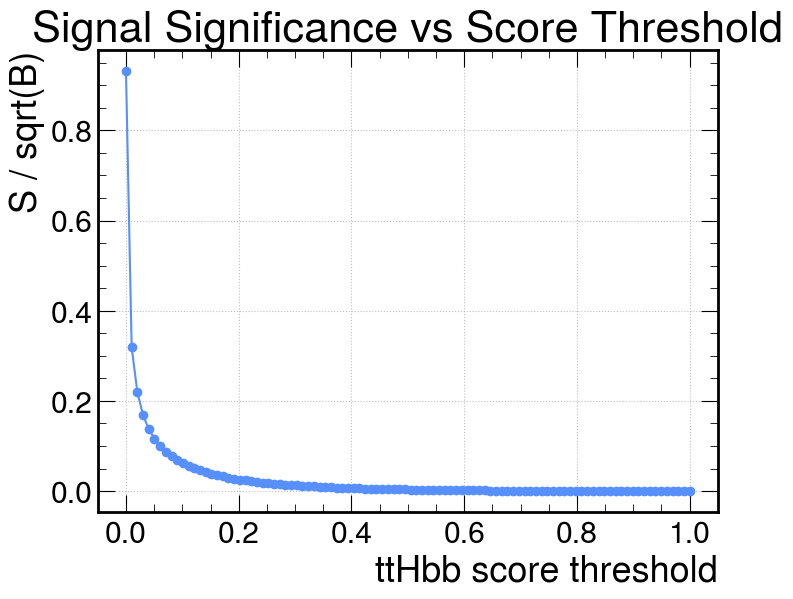

In [77]:
signal_idx = 1

signal_scores = cl_out[:, signal_idx]

is_signal = (y_true == 1)  # CAREFUL: In your script, classes seem to start from 1, not 0
is_background = ~is_signal
thresholds = np.linspace(0, 1, 100)

s_over_sqrtb = []
for thresh in thresholds:
    selected_signal = (signal_scores > thresh) & is_signal
    selected_background = (signal_scores > thresh) & is_background

    S = np.sum(weights[selected_signal])
    B = np.sum(weights[selected_background])

    if B > 0:
        s_over_sqrtb.append(S / np.sqrt(B))
    else:
        s_over_sqrtb.append(0)

plt.figure(figsize=(8,6))
plt.plot(thresholds, s_over_sqrtb, marker='o')
plt.xlabel('ttHbb score threshold')
plt.ylabel('S / sqrt(B)')
plt.title('Signal Significance vs Score Threshold')
plt.grid()
#plt.savefig(output_path + "/s_over_sqrtb.png")
plt.show()

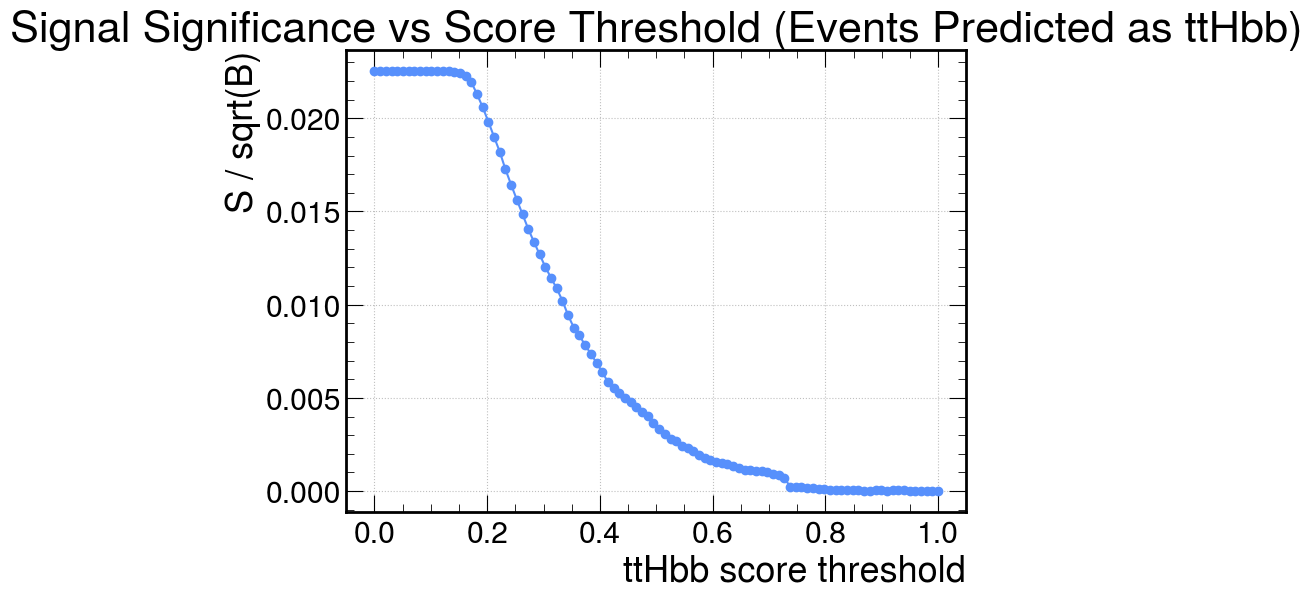

In [78]:
signal_idx = 1
y_pred = np.argmax(cl_out, axis=1)
predicted_as_signal = (y_pred == signal_idx)

signal_scores = cl_out[predicted_as_signal, signal_idx]
y_true_selected = y_true[predicted_as_signal]
weights_selected = weights[predicted_as_signal]

thresholds = np.linspace(0, 1, 100)
s_over_sqrtb = []

for thresh in thresholds:
    selected = signal_scores > thresh
    S = np.sum(weights_selected[selected & (y_true_selected == 1)])
    B = np.sum(weights_selected[selected & (y_true_selected != 1)])

    if B > 0:
        s_over_sqrtb.append(S / np.sqrt(B))
    else:
        s_over_sqrtb.append(0)

plt.figure(figsize=(8,6))
plt.plot(thresholds, s_over_sqrtb, marker='o')
plt.xlabel('ttHbb score threshold')
plt.ylabel('S / sqrt(B)')
plt.title('Signal Significance vs Score Threshold (Events Predicted as ttHbb)')
plt.grid()
#plt.savefig(output_path + "/s_over_sqrtb_predicted_as_signal.png")
plt.show()

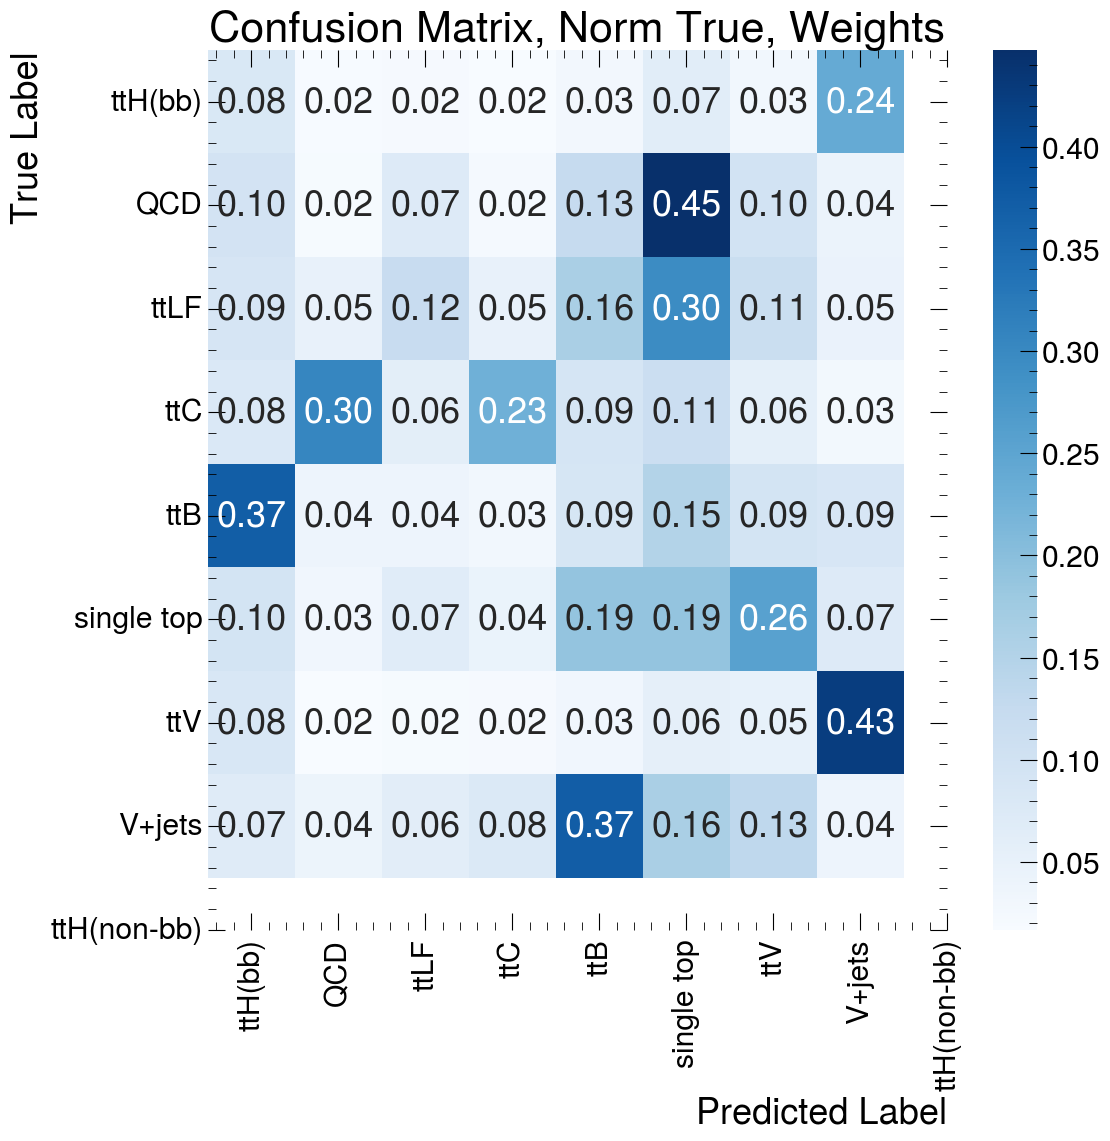

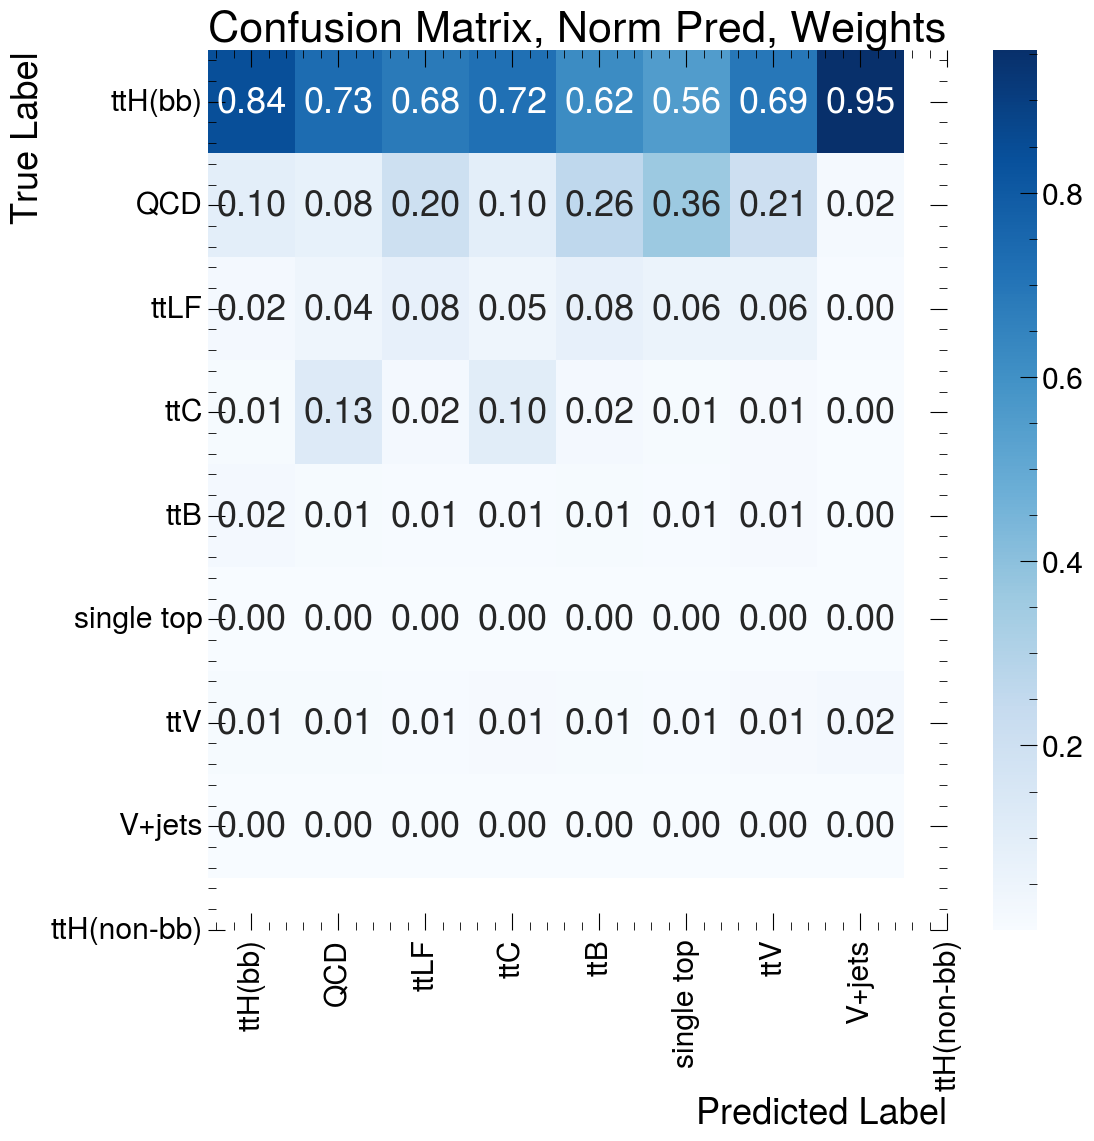

In [ ]:
out_conf_matrix = out_folder + "ConfusionMatrix.png"
plot_confusion_matrix(y_true, y_pred, out_conf_matrix, norm="true", title="Confusion Matrix, Norm True, Weights", class_names=labels, weights=weights)
#plot_confusion_matrix(y_true, y_pred, out_conf_matrix, norm="true", title="Confusion Matrix, Norm True", class_names=labels)
plot_confusion_matrix(y_true, y_pred, out_conf_matrix, norm="pred", title="Confusionr = (pred_labels["QCD"] < qcd_high) & (pred_labels["ttLF"] < ttlf_low) & (pred_labels["ttH(bb)"] > tthbb_high)
cr_ttlf = (pred_labels["QCD"] < qcd_high) & (pred_labels["ttLF"] > ttlf_high) & (pred_labels["ttH(bb)"] < tthbb_low)
#cr_ttbb = (pred_labels["QCD"] < qcd_high) & (pred_labels["tthbb_vs_ttbb"] > 1) & (pred_labels["ttH(bb)"] < tthbb_low)
cr1_definitions = {
    "inclusive": np.ones_like(pred_labels["QCD"], dtype=bool),
    "QCD veto": pred_labels["QCD"] < qcd_high,
    "SR ttHbb": tthbb_sr,
    "CR ttlf": cr_ttlf,
#    "CR_ttbb": cr_ttbb Matrix, Norm Pred, Weights", class_names=labels, weights=weights)
#plot_confusion_matrix(y_true, y_pred, out_conf_matrix, norm="pred", title="Confusion Matrix, Norm Pred", class_names=labels)

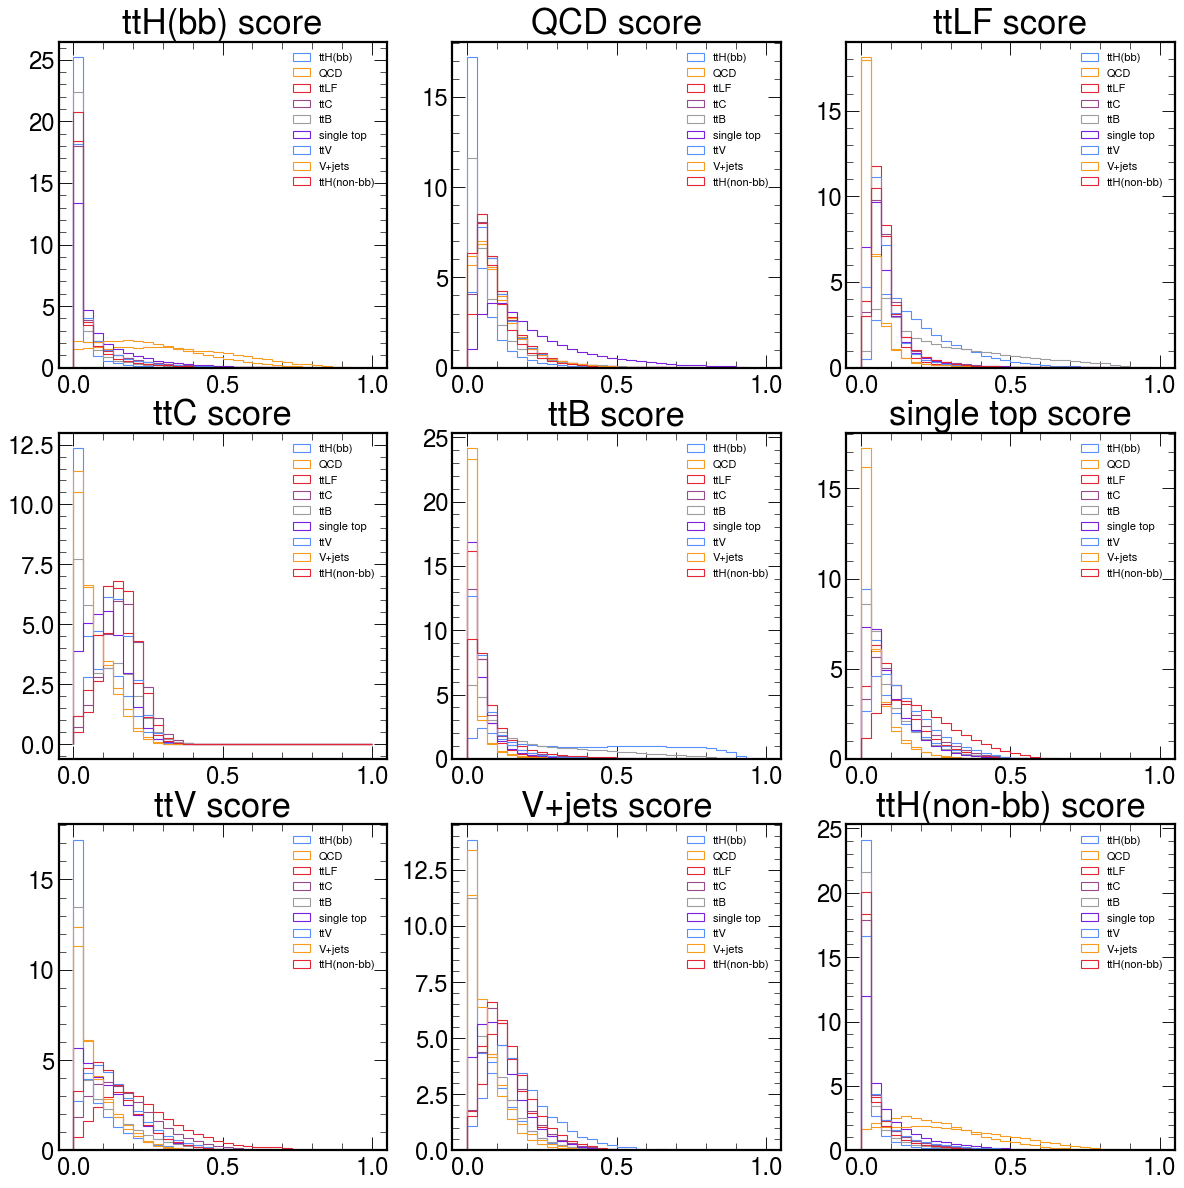

In [80]:
plt.figure(figsize=(18, 18), dpi=80)
for i in range(1,Nclasses):
    plt.subplot(3,3, i)
    for cl in range(1,Nclasses):
        mask = y_true == cl
        plt.hist(cl_out[mask,i], weights=weights[mask], range=(0,1), bins=30, histtype='step', label=labels[cl-1], density=True)
    #plt.xlabel("score")
    plt.title(f"{labels[i-1]} score")
    plt.legend(fontsize=10)
if not os.path.exists(out_folder):
    os.makedirs(out_folder)
plt.savefig(os.path.join(out_folder, "all_scores.png"), dpi=100)

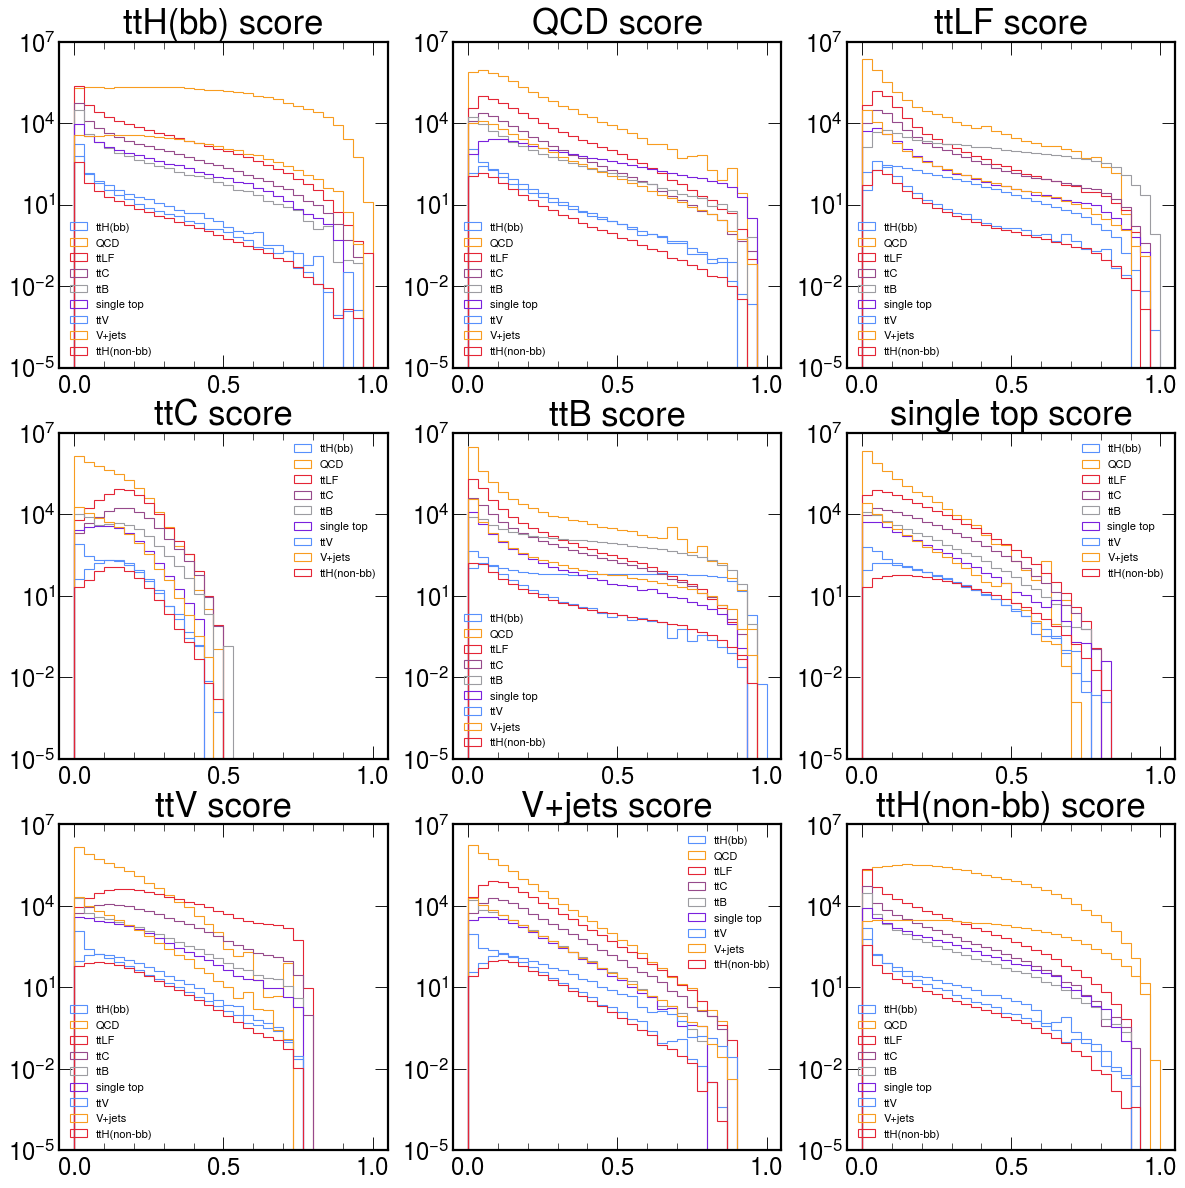

In [81]:
plt.figure(figsize=(18, 18), dpi=80)
for i in range(1,Nclasses):
    plt.subplot(3,3, i)
    for cl in range(1,Nclasses):
        mask = y_true == cl
        plt.hist(cl_out[mask,i], weights=weights[mask], range=(0,1), bins=30, histtype='step', label=labels[cl-1])
    #plt.xlabel("score")
    plt.title(f"{labels[i-1]} score")
    plt.ylim(1e-5, 1e7)
    plt.yscale("log")
    plt.legend(fontsize=10)
plt.savefig(os.path.join(out_folder, "all_log_scores.png"), dpi=100)

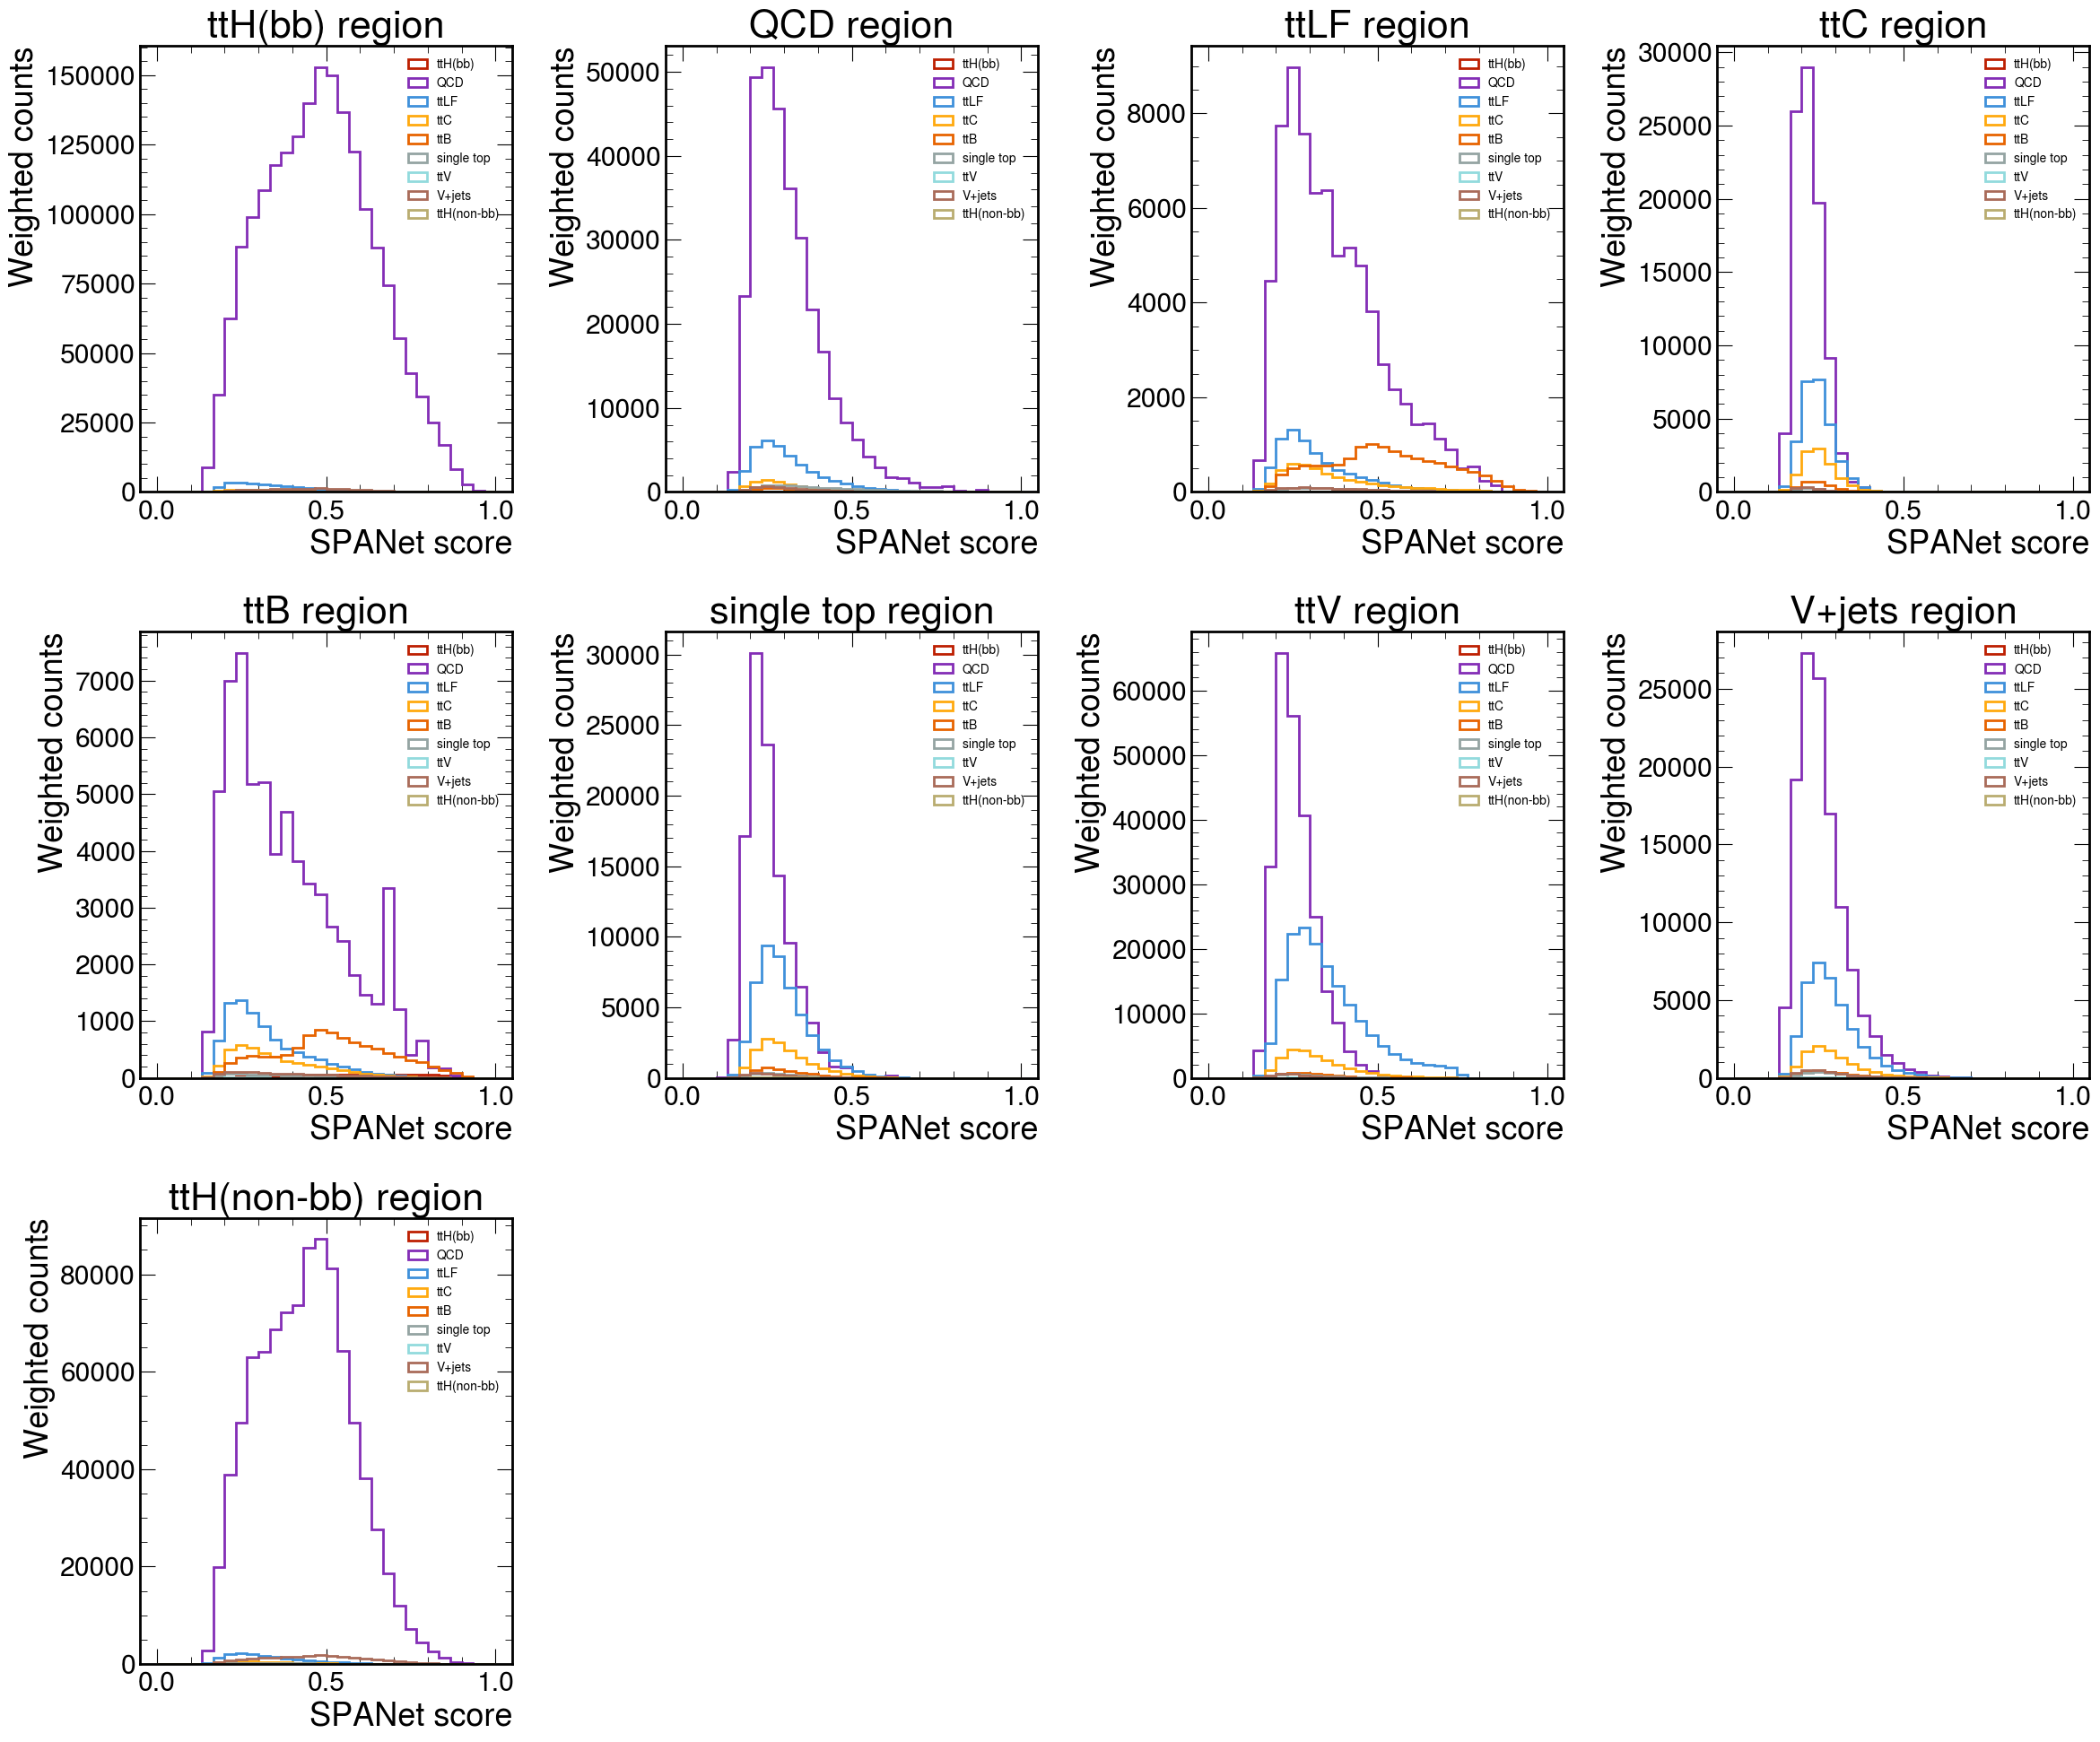

In [82]:
labels_legend = { k: k for k in labels }
labels_legend["tthbb_vs_ttbb"] = "ttHbb vs ttB"
labels_legend["tthbb_vs_ttbb_qcd"] = "ttHbb vs ttB+QCD"
labels = {v : k for k, v in mapping_encoding.items()}

CMAP_10 = [
    "#3f90da",
    "#ffa90e",
    "#bd1f01",
    "#94a4a2",
    "#832db6",
    "#a96b59",
    "#e76300",
    "#b9ac70",
    "#717581",
    "#92dadd",
]

COLOR_ALIASES = {
    "CMS_blue": CMAP_10[0],        # Blue
    "CMS_orange": CMAP_10[1],      # Orange
    "CMS_red": CMAP_10[2],         # Red
    "CMS_gray": CMAP_10[3],        # Gray
    "CMS_purple": CMAP_10[4],      # Purple
    "CMS_brown": CMAP_10[5],       # Brown
    "CMS_dark_orange": CMAP_10[6], # Dark Orange
    "CMS_beige": CMAP_10[7],       # Beige
    "CMS_dark_gray": CMAP_10[8],   # Dark Gray
    "CMS_light_blue": CMAP_10[9]   # Light Blue
}

colors = {
    "ttH(bb)": COLOR_ALIASES["CMS_red"],
    "QCD": COLOR_ALIASES["CMS_purple"],
    "ttB": COLOR_ALIASES["CMS_dark_orange"],
    "ttC": COLOR_ALIASES["CMS_orange"],
    "ttLF": COLOR_ALIASES["CMS_blue"],
    "single top": COLOR_ALIASES["CMS_gray"],
    "ttV": COLOR_ALIASES["CMS_light_blue"],
    "V+jets": COLOR_ALIASES["CMS_brown"],
    "VV": COLOR_ALIASES["CMS_dark_gray"],
    "ttH(non-bb)": COLOR_ALIASES["CMS_beige"],
}

# Fixed argmax-based control-region plotting (no 0/1 mismatch; uses pred_labels and true_labels directly)
node_names = list(labels.keys())
# compute 0-based winner index per event
class_idx = np.argmax(np.stack([np.asarray(pred_labels[name]) for name in node_names], axis=1), axis=1)

fig, axs = plt.subplots(3, 4, figsize=[24,20], dpi=100)
axs = axs.flatten()

for i, region in enumerate(node_names):
    ax = axs[i]
    region_mask = (class_idx == i)  # compare to 0-based index

    for label in node_names:
        mask_by_sample = np.asarray(true_labels[label], dtype=bool)
        n = int(np.sum(region_mask & mask_by_sample))
        #print(f"CR: {region}, class: {label} -> events: {n}")
        if n == 0:
            continue
        ax.hist(
            np.asarray(pred_labels[region])[mask_by_sample & region_mask],
            weights=weights[mask_by_sample & region_mask],
            bins=30, range=(0,1), histtype='step',
            color=colors.get(label), label=labels_legend.get(label, label),linewidth=2
        )
    ax.set_title(f"{labels_legend.get(region, region)} region")
    ax.set_xlabel("SPANet score")
    ax.set_ylabel("Weighted counts")
    ax.legend(fontsize=10)

# turn off remaining axes
for ax in axs[len(node_names):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(os.path.join(out_folder, "control_regions_argmax_fixed.png"), dpi=300)
plt.show()


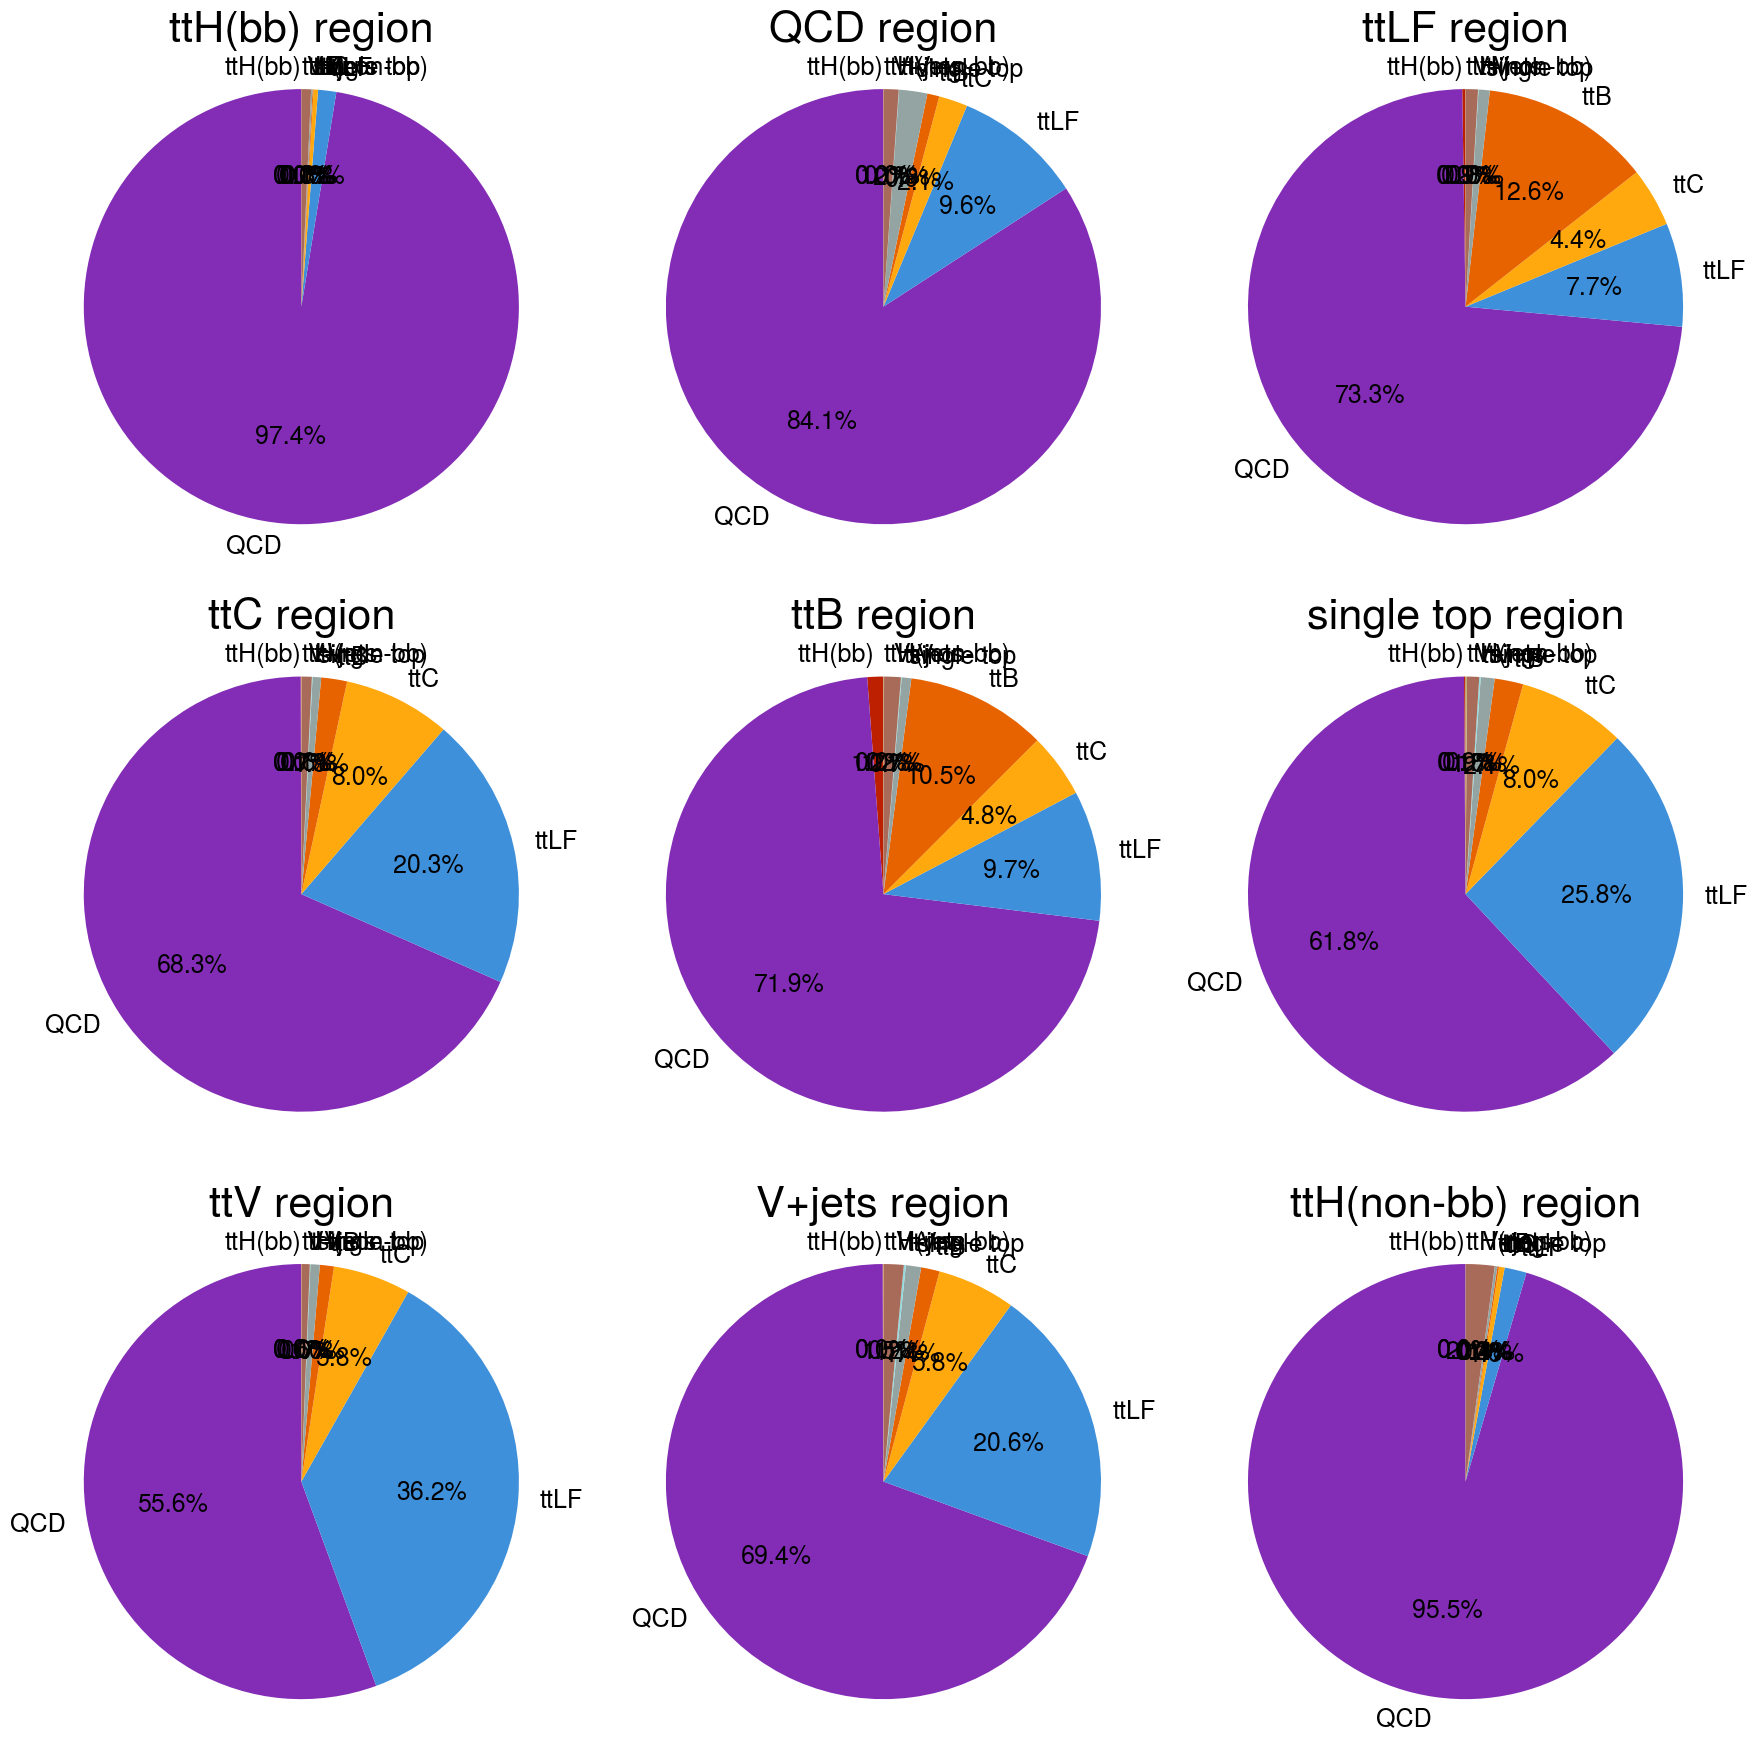

In [83]:
labels_to_plot = {
 'ttH(bb)': 1,
 'QCD': 2,
 'ttLF': 3,
 'ttC': 4,
 'ttB': 5,
 'single top': 6,
 'ttV': 7,
 'V+jets': 8,
 'ttH(non-bb)': 9
}

# now display the pie chart for each region with the relative contribution of each sample
fig, axs = plt.subplots(3, 3, figsize=[18,18], dpi=100)
axs = axs.flatten()
for i, region in enumerate(labels_to_plot.keys()): 
    ax = axs[i]
    region_mask = (class_idx == i)  # compare to 0-based index
    sample_weights = []
    sample_labels = []
    for label in labels_to_plot.keys():
        mask_by_sample = np.asarray(true_labels[label], dtype=bool)
        w = np.sum(weights[mask_by_sample & region_mask])
        if w > 0:
            sample_weights.append(w)
            # use labels_to_plot to get the label name for the legend, otherwise use the label itself
            sample_labels.append(labels_legend.get(label, label))
    if len(sample_weights) > 0:
        ax.pie(sample_weights, labels=sample_labels, autopct='%1.1f%%', startangle=90, colors=[colors.get(label) for label in labels.keys()], textprops={'fontsize': 18})
        ax.set_title(f"{labels_legend.get(region, region)} region", pad=20)
    else:
        ax.text(0.5, 0.5, 'No events', horizontalalignment='center', verticalalignment='center')
        ax.set_title(f"{labels_legend.get(region, region)} region")
    ax.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.
# turn off remaining axes
for ax in axs[len(labels_to_plot.keys()):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(os.path.join(out_folder, "control_regions_pie_charts.png"), dpi=300)
plt.show()

In [84]:
# Build new pred labels with Neyman-Pearson lemma
pred_labels["tthbb_vs_ttbb"] = pred_labels["ttH(bb)"] / (pred_labels["ttH(bb)"] + pred_labels["ttB"] + 1e-6) # add small number to avoid division by zero
# Define tthbb vs ttbb+qcd
pred_labels["tthbb_vs_ttbb_qcd"] = pred_labels["ttH(bb)"] / (pred_labels["ttH(bb)"] + pred_labels["ttB"] + pred_labels["QCD"] + 1e-6)
pred_labels

{'ttH(bb)': array([0.06145763, 0.48412293, 0.11427053, ..., 0.03515174, 0.00337888,
        0.2353857 ], dtype=float32),
 'QCD': array([0.14795372, 0.10953342, 0.13057391, ..., 0.07494116, 0.06715322,
        0.1264236 ], dtype=float32),
 'ttLF': array([0.05975766, 0.01428879, 0.03360589, ..., 0.08708841, 0.08422204,
        0.05859818], dtype=float32),
 'ttC': array([0.15410632, 0.02521097, 0.08950739, ..., 0.20716944, 0.19171083,
        0.14063215], dtype=float32),
 'ttB': array([0.02687002, 0.00740377, 0.02921626, ..., 0.03338196, 0.03735789,
        0.00897488], dtype=float32),
 'single top': array([0.0868238 , 0.01085287, 0.13641694, ..., 0.0942652 , 0.16842833,
        0.02437638], dtype=float32),
 'ttV': array([0.21554317, 0.03590801, 0.06430157, ..., 0.24970135, 0.1934551 ,
        0.13996905], dtype=float32),
 'V+jets': array([0.18520801, 0.02032047, 0.25461876, ..., 0.1829653 , 0.2488914 ,
        0.05411101], dtype=float32),
 'ttH(non-bb)': array([0.06227965, 0.29235876, 0.

In [85]:
# now compute the percentages of each sample in each region obtained from the SPANet score definition of the CRs
ttlf_low = 0.2
ttlf_high = 0.3
tthbb_low = 0.6
tthbb_high = 0.8
#ttcc_high = 0.3
qcd_high = 0.001
tthbb_sr = (pred_labels["QCD"] < qcd_high) & (pred_labels["ttLF"] < ttlf_low) & (pred_labels["ttH(bb)"] > tthbb_high)
cr_ttlf = (pred_labels["QCD"] < qcd_high) & (pred_labels["ttLF"] > ttlf_high) & (pred_labels["ttH(bb)"] < tthbb_low)
#cr_ttbb = (pred_labels["QCD"] < qcd_high) & (pred_labels["tthbb_vs_ttbb"] > 1) & (pred_labels["ttH(bb)"] < tthbb_low)
cr1_definitions = {
    "inclusive": np.ones_like(pred_labels["QCD"], dtype=bool),
    "QCD veto": pred_labels["QCD"] < qcd_high,
    "SR ttHbb": tthbb_sr,
    "CR ttlf": cr_ttlf,
#    "CR_ttbb": cr_ttbb
}

In [86]:
labels_to_plot = {
 'ttH(bb)': 1,
 'QCD': 2,
 'ttLF': 3,
 'ttC': 4,
 'ttB': 5,
 'single top': 6,
 #'ttV': 7,
 #'V+jets': 8,
 'ttH(non-bb)': 9,
 'tthbb_vs_ttbb': None,
 'tthbb_vs_ttbb_qcd': None
}
pred_labels_to_plot = {k : v for k, v in pred_labels.items() if k in labels_to_plot.keys()}

In [87]:
pred_labels_to_plot

{'ttH(bb)': array([0.06145763, 0.48412293, 0.11427053, ..., 0.03515174, 0.00337888,
        0.2353857 ], dtype=float32),
 'QCD': array([0.14795372, 0.10953342, 0.13057391, ..., 0.07494116, 0.06715322,
        0.1264236 ], dtype=float32),
 'ttLF': array([0.05975766, 0.01428879, 0.03360589, ..., 0.08708841, 0.08422204,
        0.05859818], dtype=float32),
 'ttC': array([0.15410632, 0.02521097, 0.08950739, ..., 0.20716944, 0.19171083,
        0.14063215], dtype=float32),
 'ttB': array([0.02687002, 0.00740377, 0.02921626, ..., 0.03338196, 0.03735789,
        0.00897488], dtype=float32),
 'single top': array([0.0868238 , 0.01085287, 0.13641694, ..., 0.0942652 , 0.16842833,
        0.02437638], dtype=float32),
 'ttH(non-bb)': array([0.06227965, 0.29235876, 0.14748876, ..., 0.03533543, 0.00540228,
        0.21152909], dtype=float32),
 'tthbb_vs_ttbb': array([0.6957837 , 0.98493516, 0.796378  , ..., 0.5129042 , 0.08294226,
        0.96326804], dtype=float32),
 'tthbb_vs_ttbb_qcd': array([0.260

In [88]:
mask_tthbb_sr = {}
for sample in labels:
    mask_tthbb_sr[sample] = true_labels[sample] & cr1_definitions["SR ttHbb"]

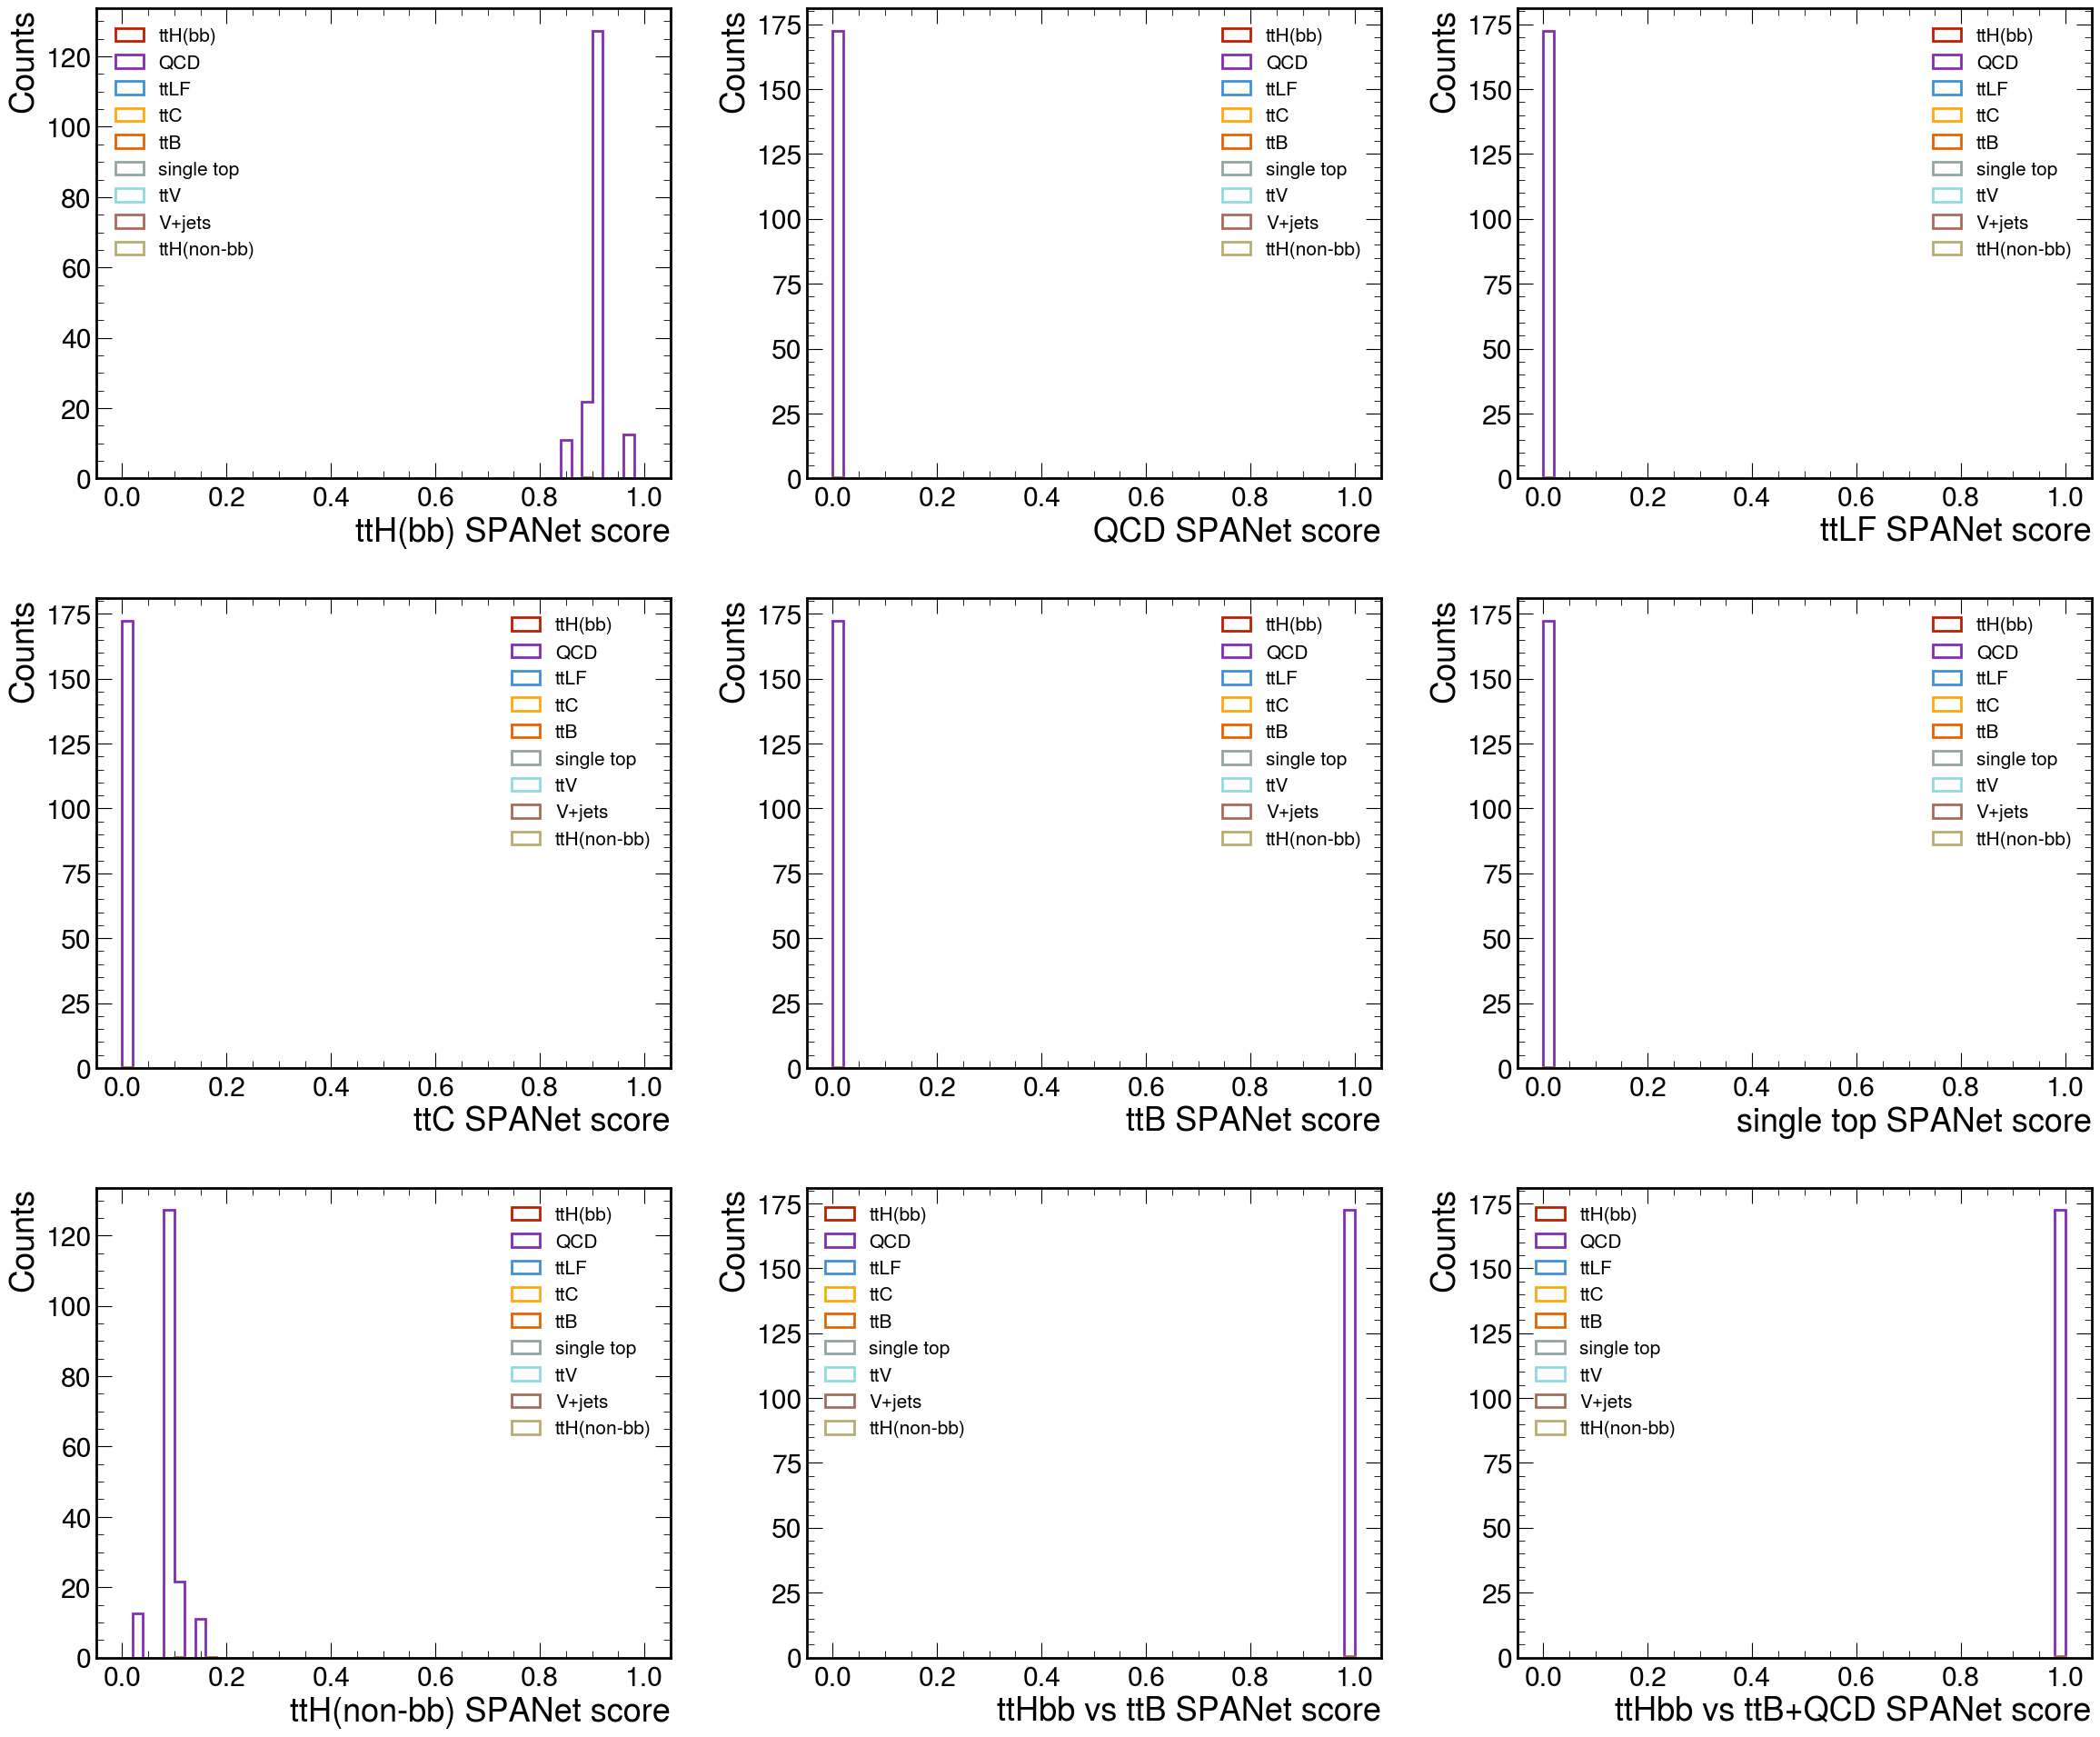

In [89]:
plot_scores(mask_tthbb_sr, pred_labels_to_plot, plot_dir=out_folder, weights=weights, density=False)

/tmp/ipykernel_14919/1420375628.py:15: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


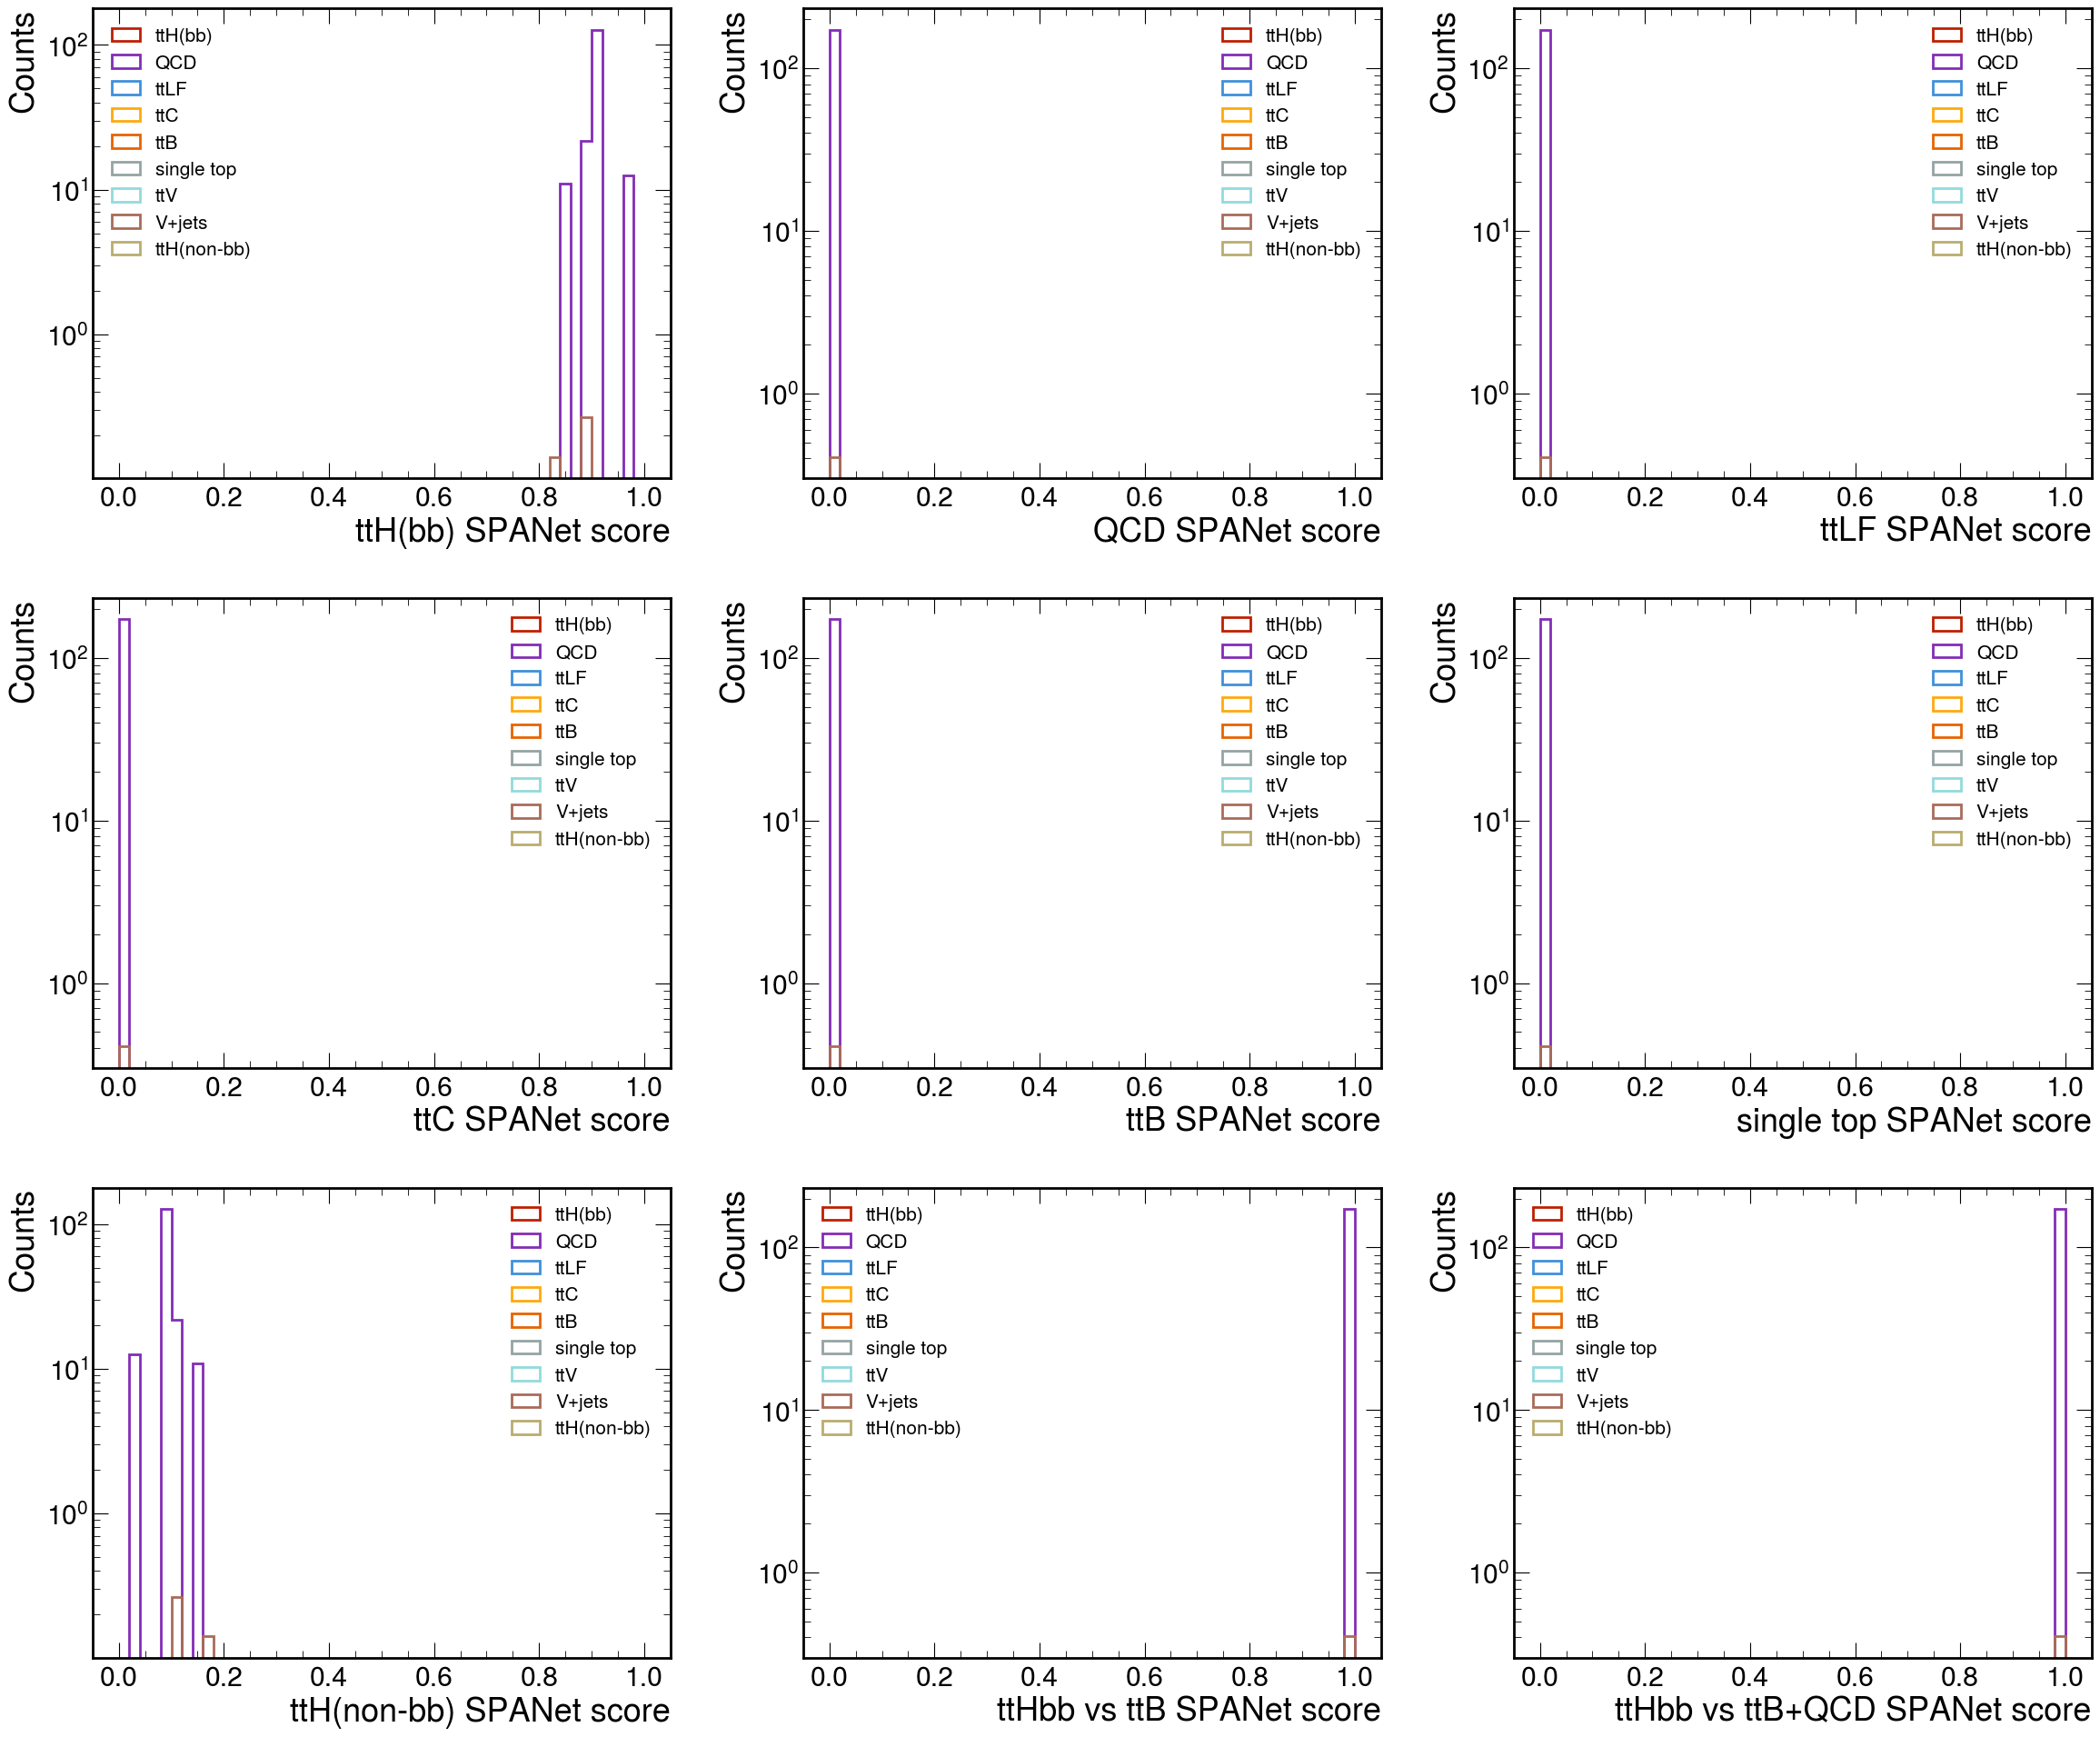

In [90]:
plot_scores(mask_tthbb_sr, pred_labels_to_plot, plot_dir=out_folder, weights=weights, density=False, log=True)

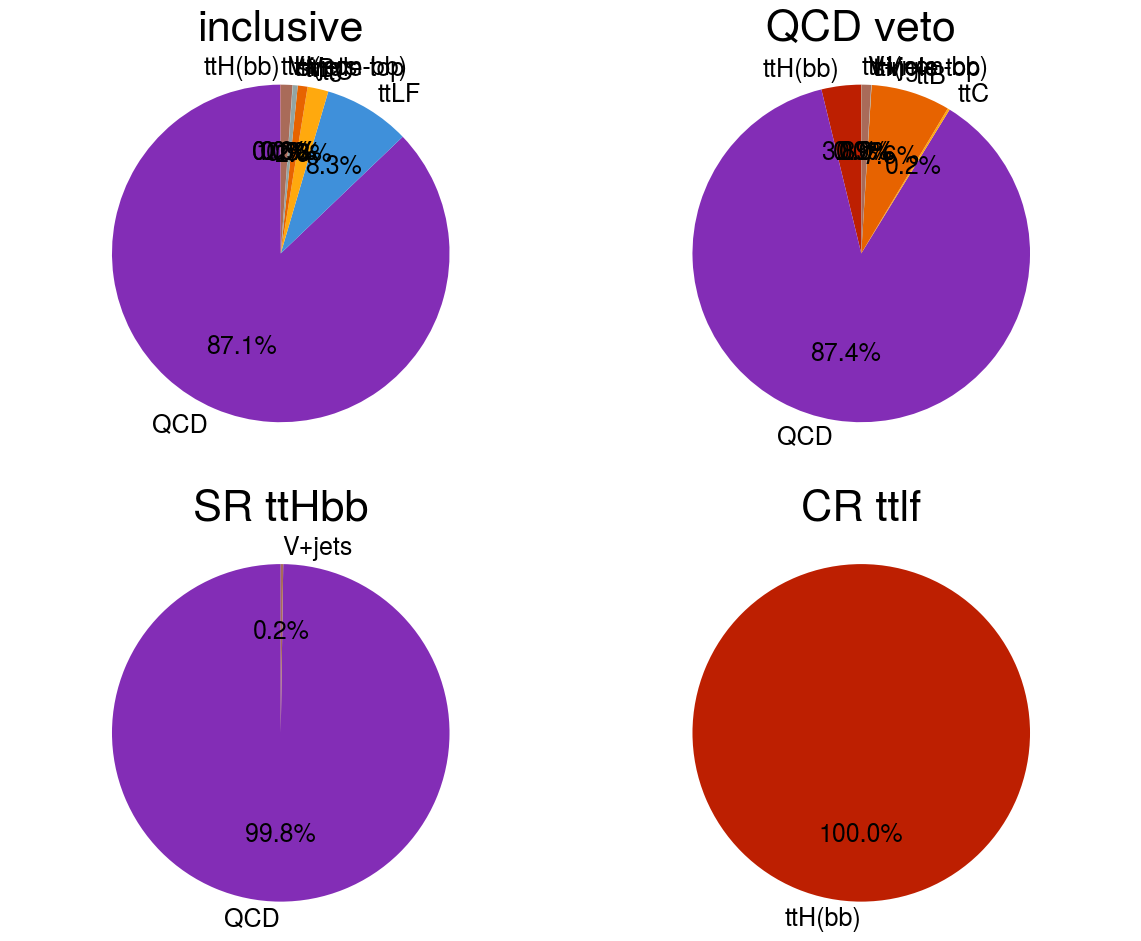

In [91]:
samples = list(true_labels.keys())

# make a pie chart for each control region with the relative contribution of each sample
fig, axs = plt.subplots(2, 2, figsize=[12,10], dpi=100)
axs = axs.flatten()
for i, (region_name, region_mask) in enumerate(cr1_definitions.items()):
    ax = axs[i]

    sample_counts = []
    sample_labels = []
    sample_colors = []

    for sample_key in samples:
        mask_by_sample = np.asarray(true_labels[sample_key], dtype=bool)
        count = np.sum(weights[mask_by_sample & region_mask])
        if count > 0:
            sample_counts.append(count)
            sample_labels.append(labels_legend.get(sample_key, sample_key))
            sample_colors.append(colors.get(sample_key))

    total_region_events = np.sum(sample_counts)

    if total_region_events > 0:
        ax.pie(
            sample_counts,
            labels=sample_labels,
            autopct=lambda pct: f"{pct:.1f}%",
            startangle=90,
            colors=sample_colors,
            textprops={'fontsize': 18},
        )
        ax.set_title(f"{region_name}", pad=20)
    else:
        ax.text(0.5, 0.5, 'No events', horizontalalignment='center', verticalalignment='center')
        ax.set_title(f"{region_name}")

    ax.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.

fig.tight_layout()
fig.savefig(os.path.join(out_folder, f"control_regions_tthbb_score_SR.png"), dpi=300)
plt.show()

In [92]:
jet_pt = jet_input[:,:,0]
jet_btag_M = jet_input[:,:,4]
jet_btag_M

NameError: name 'jet_input' is not defined

In [ ]:
njet = ak.sum(jet_pt > 0, axis=1)
nbjet = ak.sum(jet_btag_M == 1, axis=1)
nbjet

<Array [1, 2, 3, 2, 2, 1, ... 2, 2, 1, 1, 1, 1] type='12393614 * int64'>

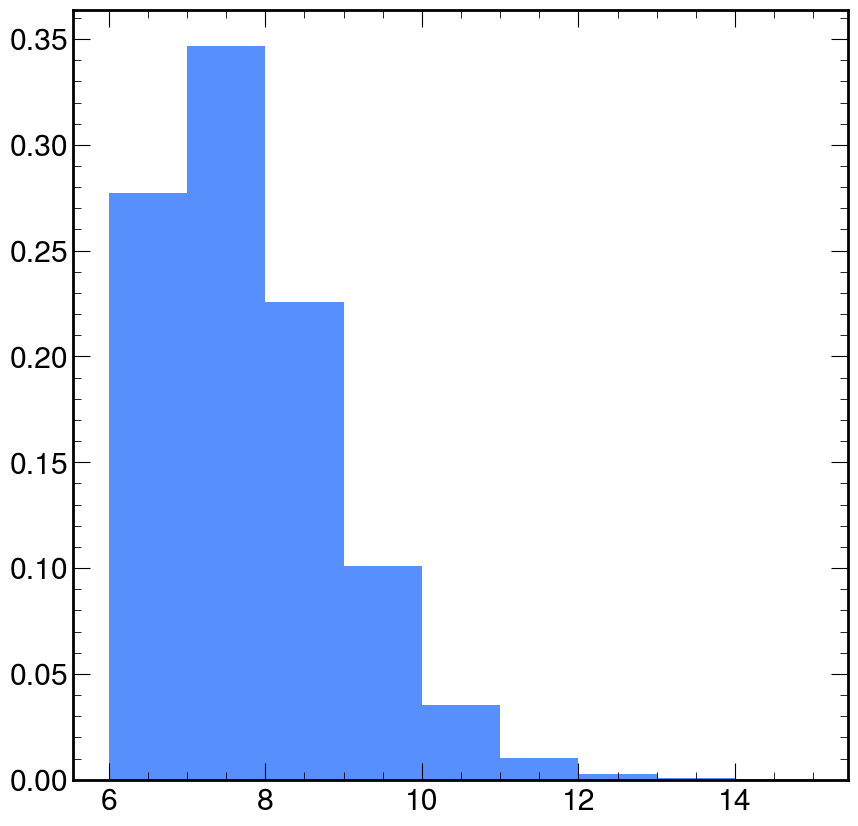

In [ ]:
plt.hist(njet, bins=np.arange(6, 16), density=True);

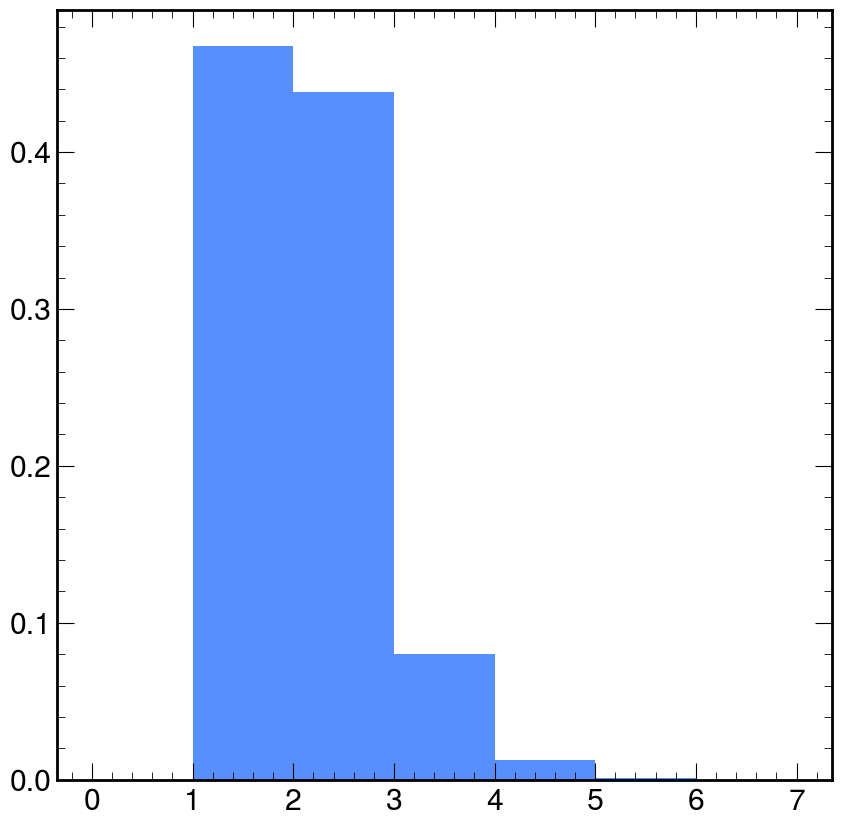

In [ ]:
plt.hist(nbjet, bins=np.arange(0, 8), density=True);
